# Girls-at-Risk Early Warning — ML Pipeline

## Phase 1: Problem Framing (Ch. 1)

**Business problem:** Lighthouse Sanctuary operates multiple safehouses for girls who are survivors of sexual abuse or sex trafficking. With limited staff managing cases across several facilities, the organization needs to know **which residents are most likely to experience any incident in the near future** (not only the most severe) so that social workers can prioritize attention, adjust intervention plans, and allocate resources proactively rather than reactively.

**Target definition:** For each resident at a given point in time, predict the probability that she will have **at least one row in `incident_reports`** (any `severity`: Low, Medium, or High) with `incident_date` in the **next 30 days** after the cutoff. This broadens the positive class so the model can learn from more events while still supporting early warning.

**Who cares about this:**
- **Safehouse staff & social workers** — daily triage decisions about who to check on first
- **Program director** — resource allocation across safehouses
- **Case conference participants** — data-informed intervention planning

**Success metrics:**
- **ROC-AUC ≥ 0.80** (primary) — robust to class imbalance
- **Recall ≥ 0.70** — missing an at-risk girl (false negative) is far more costly than flagging a girl who turns out fine (false positive). In this context, a false negative could mean a missed opportunity to prevent self-harm, a runaway attempt, or another crisis. A false positive means extra attention for a resident who may not need it urgently — an acceptable cost.

**Modeling goal: Predictive.** The purpose of this pipeline is to generate reliable probability scores that can be operationalized in a staff dashboard, not to establish causal relationships. We will discuss feature importance to provide intuition for staff, but we will not claim that associations are causal.

**CRISP-DM phases covered:** Business Understanding → Data Understanding → Data Preparation → Modeling → Evaluation → Deployment

**Output format:** Every active resident receives a **raw risk probability** (0–1) from `predict_proba`, plus a **cohort bucket** for triage:
- **High / Medium / Low** = **within-cohort tertiles** on that day (≈ top third / middle third / bottom third of predicted risk among active residents). This avoids “everyone is Low” when raw scores are all below an arbitrary 0.33 cutoff.
- **Interpretation:** “High” means **highest relative priority among peers today**, not “objectively 66%+ chance of an incident.” Staff should still read the **numeric probability**.

## Phase 2: Data Understanding (Ch. 4, 6, 8)

In [25]:
import sys, json, warnings
from datetime import datetime, timedelta
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

import importlib
sys.path.insert(0, '.')
import function
importlib.reload(function)
from function import (
    univariate, basic_wrangling, bin_categories,
    handle_missing_data, normalize, manage_outliers
)

from sklearn.model_selection import (
    TimeSeriesSplit, cross_validate, GridSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay,
    precision_recall_curve, average_precision_score,
)

from sklearn.feature_selection import SelectFromModel
from sklearn.inspection import permutation_importance

import joblib

print('All imports successful')

All imports successful


### Data Acquisition (Ch. 4)

Load all relevant CSVs from the Lighthouse database. Nine tables are needed:
- **residents** — anchor table, one row per girl (60 residents)
- **incident_reports** — target source (severity column is the key)
- **process_recordings** — counseling session logs
- **education_records** — education attendance and progress
- **health_wellbeing_records** — monthly health scores
- **home_visitations** — family visit records
- **intervention_plans** — case plans per resident
- **safehouses** — facility metadata
- **safehouse_monthly_metrics** — facility-level aggregates by month

In [26]:
DATA = 'lighthouse_csv_v7/'

residents       = pd.read_csv(DATA + 'residents.csv', parse_dates=[
    'date_of_birth','date_of_admission','date_closed','created_at',
    'date_colb_registered','date_colb_obtained','date_case_study_prepared','date_enrolled'])
incidents       = pd.read_csv(DATA + 'incident_reports.csv', parse_dates=['incident_date','resolution_date'])
recordings      = pd.read_csv(DATA + 'process_recordings.csv', parse_dates=['session_date'])
education       = pd.read_csv(DATA + 'education_records.csv', parse_dates=['record_date'])
health          = pd.read_csv(DATA + 'health_wellbeing_records.csv', parse_dates=['record_date'])
visitations     = pd.read_csv(DATA + 'home_visitations.csv', parse_dates=['visit_date'])
interventions   = pd.read_csv(DATA + 'intervention_plans.csv', parse_dates=['target_date','case_conference_date','created_at','updated_at'])
safehouses      = pd.read_csv(DATA + 'safehouses.csv', parse_dates=['open_date'])
monthly_metrics = pd.read_csv(DATA + 'safehouse_monthly_metrics.csv', parse_dates=['month_start','month_end'])

tables = {
    'residents': residents, 'incidents': incidents, 'recordings': recordings,
    'education': education, 'health': health, 'visitations': visitations,
    'interventions': interventions, 'safehouses': safehouses, 'monthly_metrics': monthly_metrics
}

for name, tbl in tables.items():
    print(f"\n{'='*50}\n{name}  —  {tbl.shape[0]} rows × {tbl.shape[1]} cols")
    print(tbl.dtypes.to_string())


residents  —  60 rows × 49 cols
resident_id                          int64
case_control_no                     object
internal_code                       object
safehouse_id                         int64
case_status                         object
sex                                 object
date_of_birth               datetime64[ns]
birth_status                        object
place_of_birth                      object
religion                            object
case_category                       object
sub_cat_orphaned                      bool
sub_cat_trafficked                    bool
sub_cat_child_labor                   bool
sub_cat_physical_abuse                bool
sub_cat_sexual_abuse                  bool
sub_cat_osaec                         bool
sub_cat_cicl                          bool
sub_cat_at_risk                       bool
sub_cat_street_child                  bool
sub_cat_child_with_hiv                bool
is_pwd                                bool
pwd_type             

### Explore Raw Tables (Ch. 6, 8)

Run `univariate()` on the two most critical tables (residents, incidents) to understand distributions, missingness, and data types. Then check date ranges across all time-indexed tables to determine valid cutoff months.

UNIVARIATE — residents


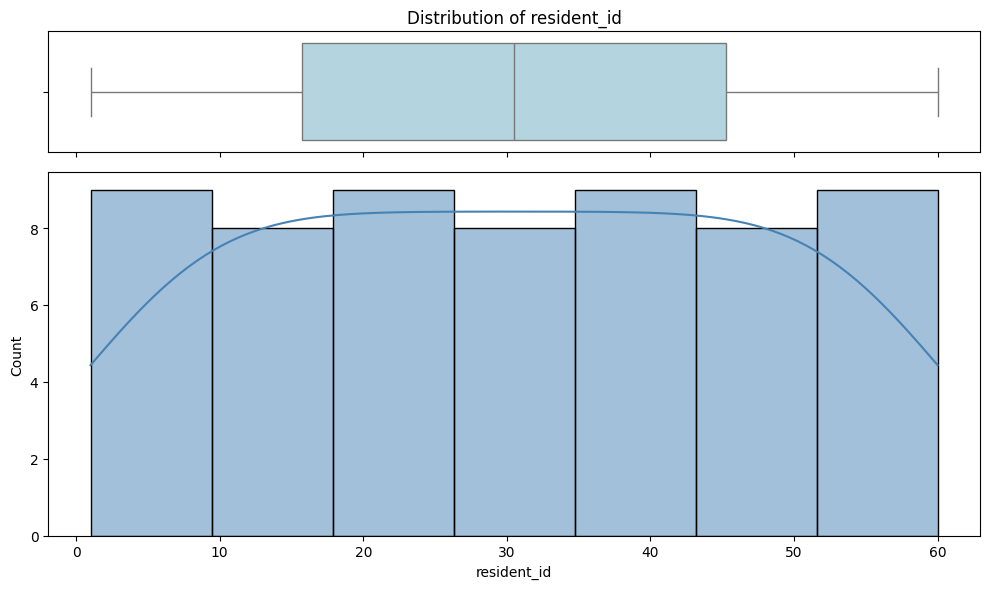

Column 'case_control_no' has too many unique values (60) for plotting. Skipping visualization.
Column 'internal_code' has too many unique values (60) for plotting. Skipping visualization.


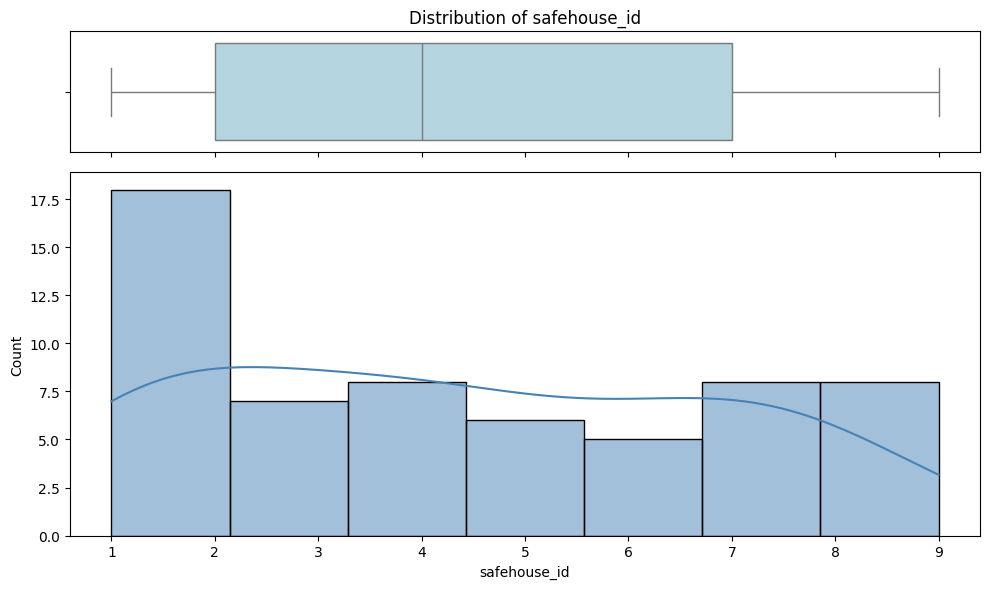

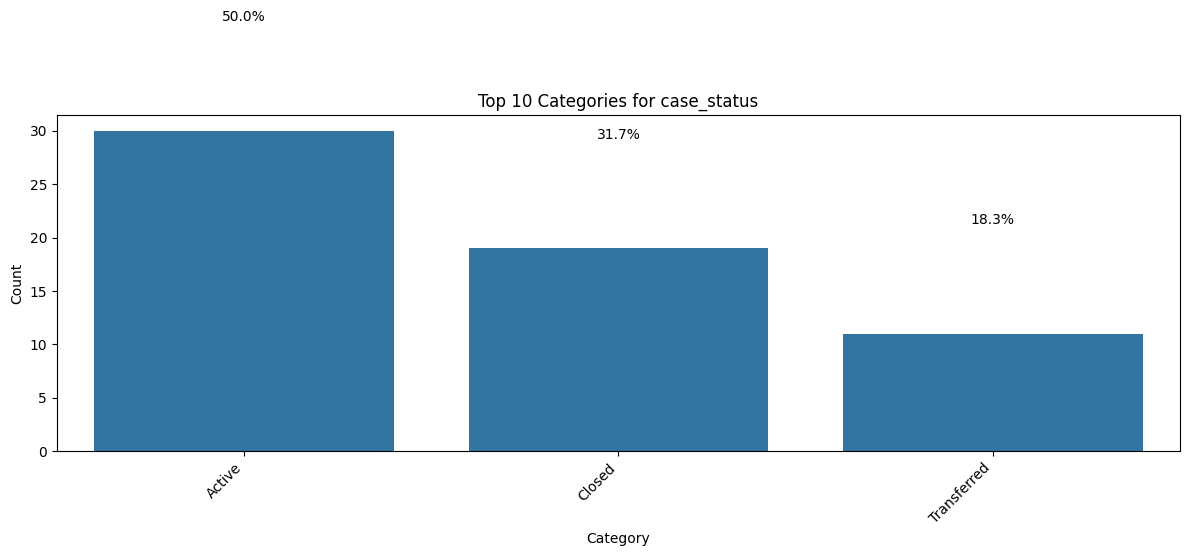

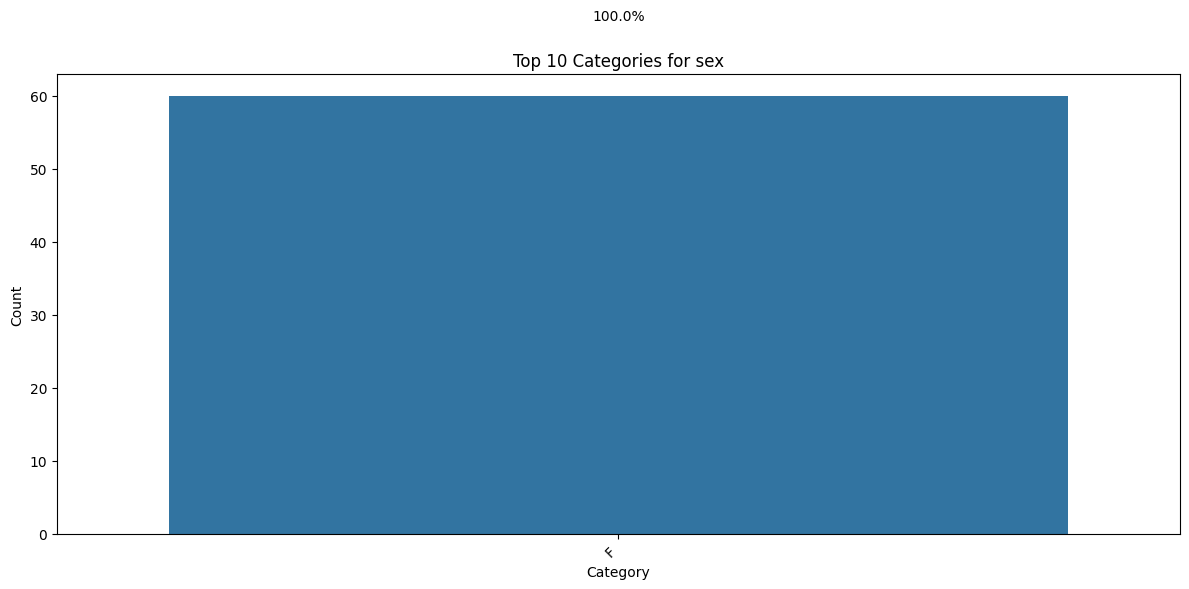

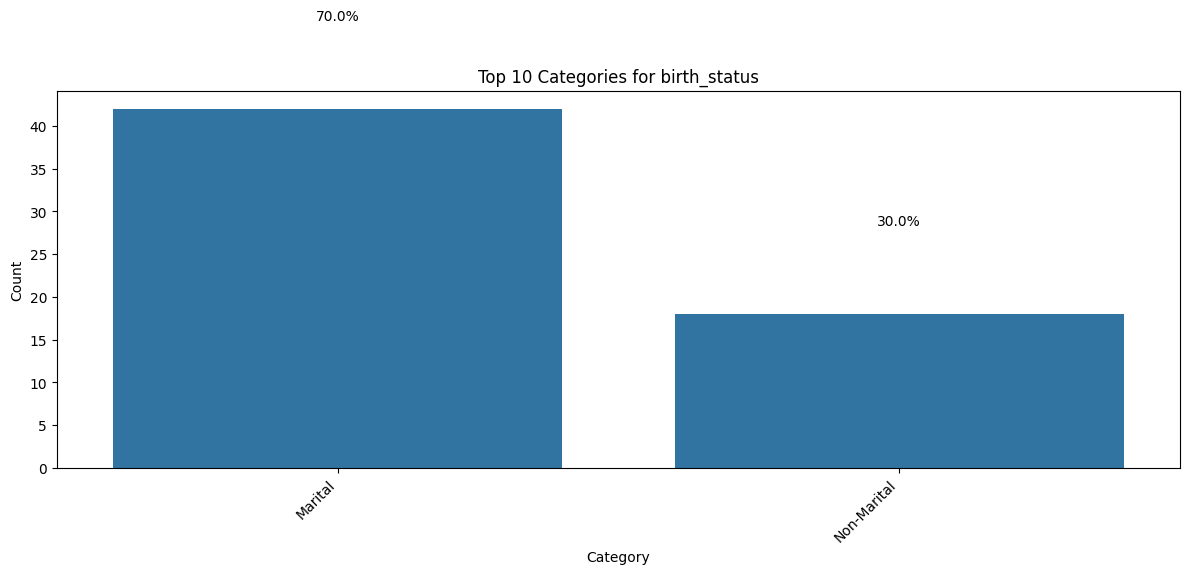

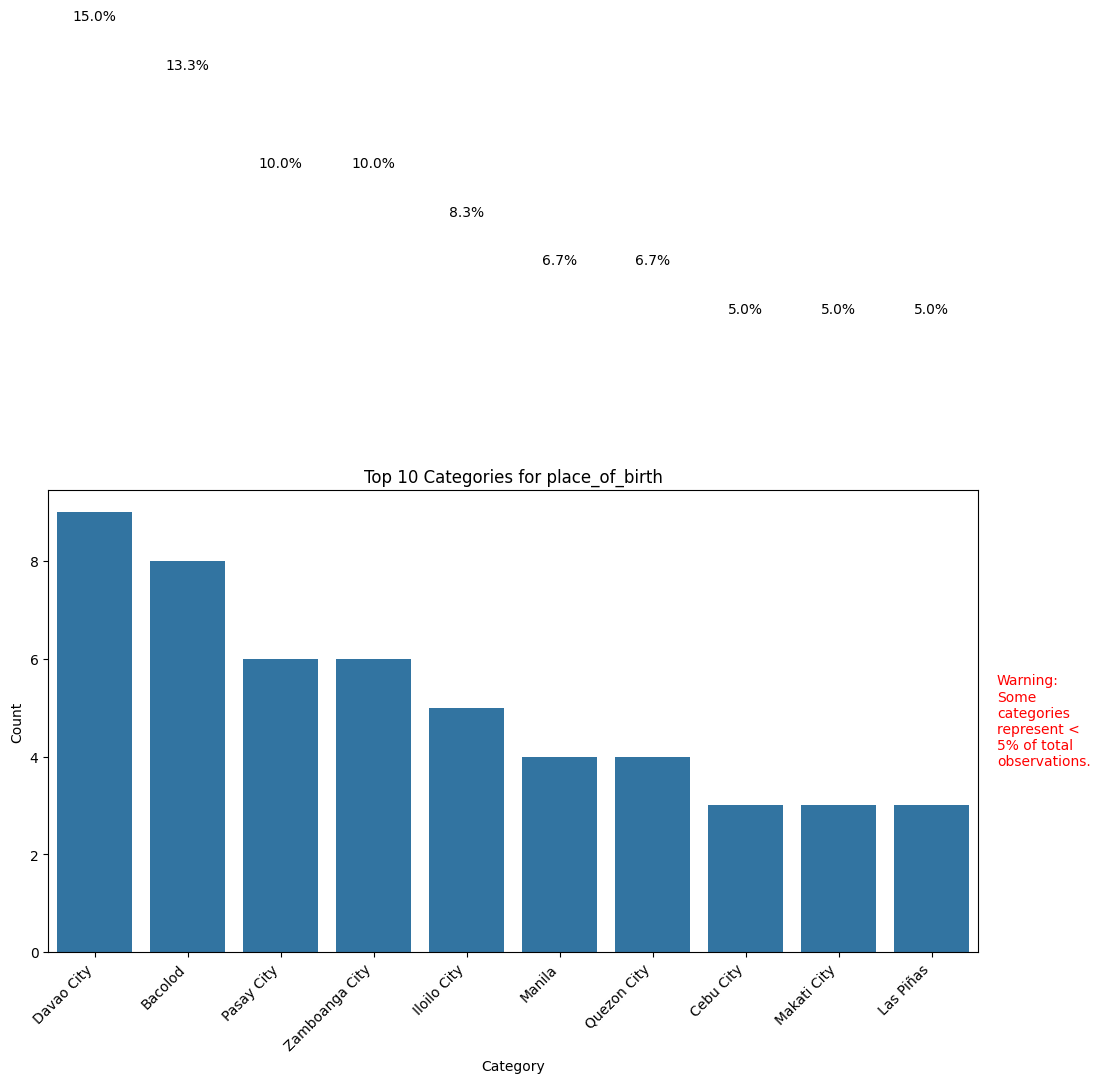

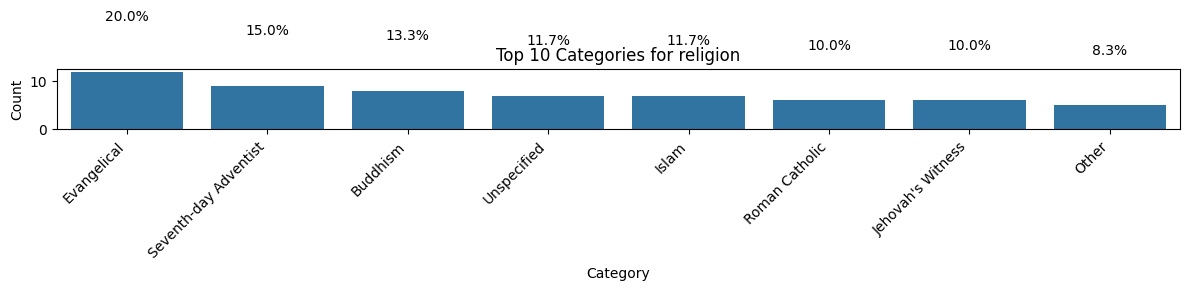

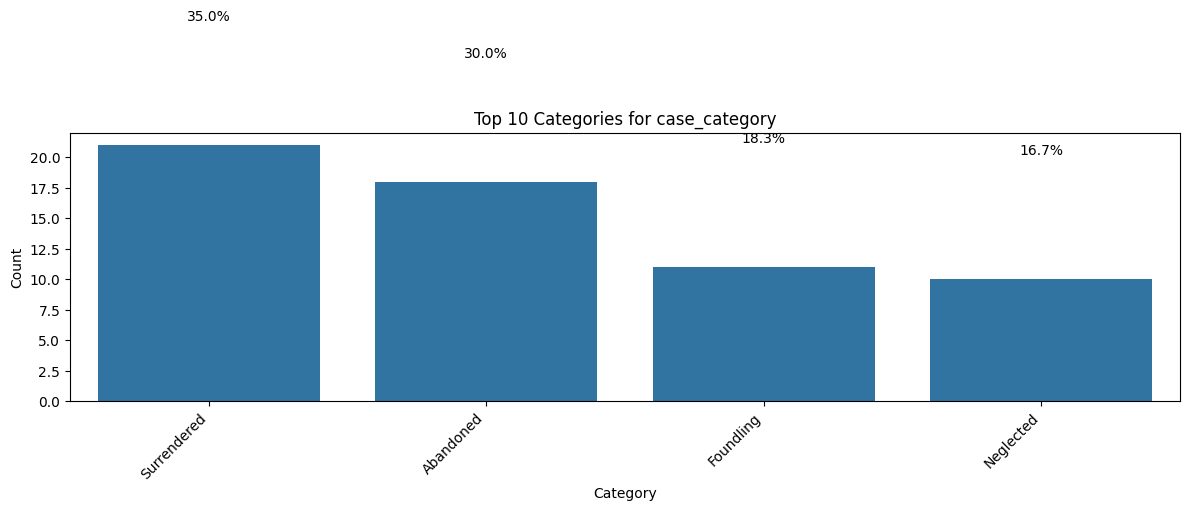

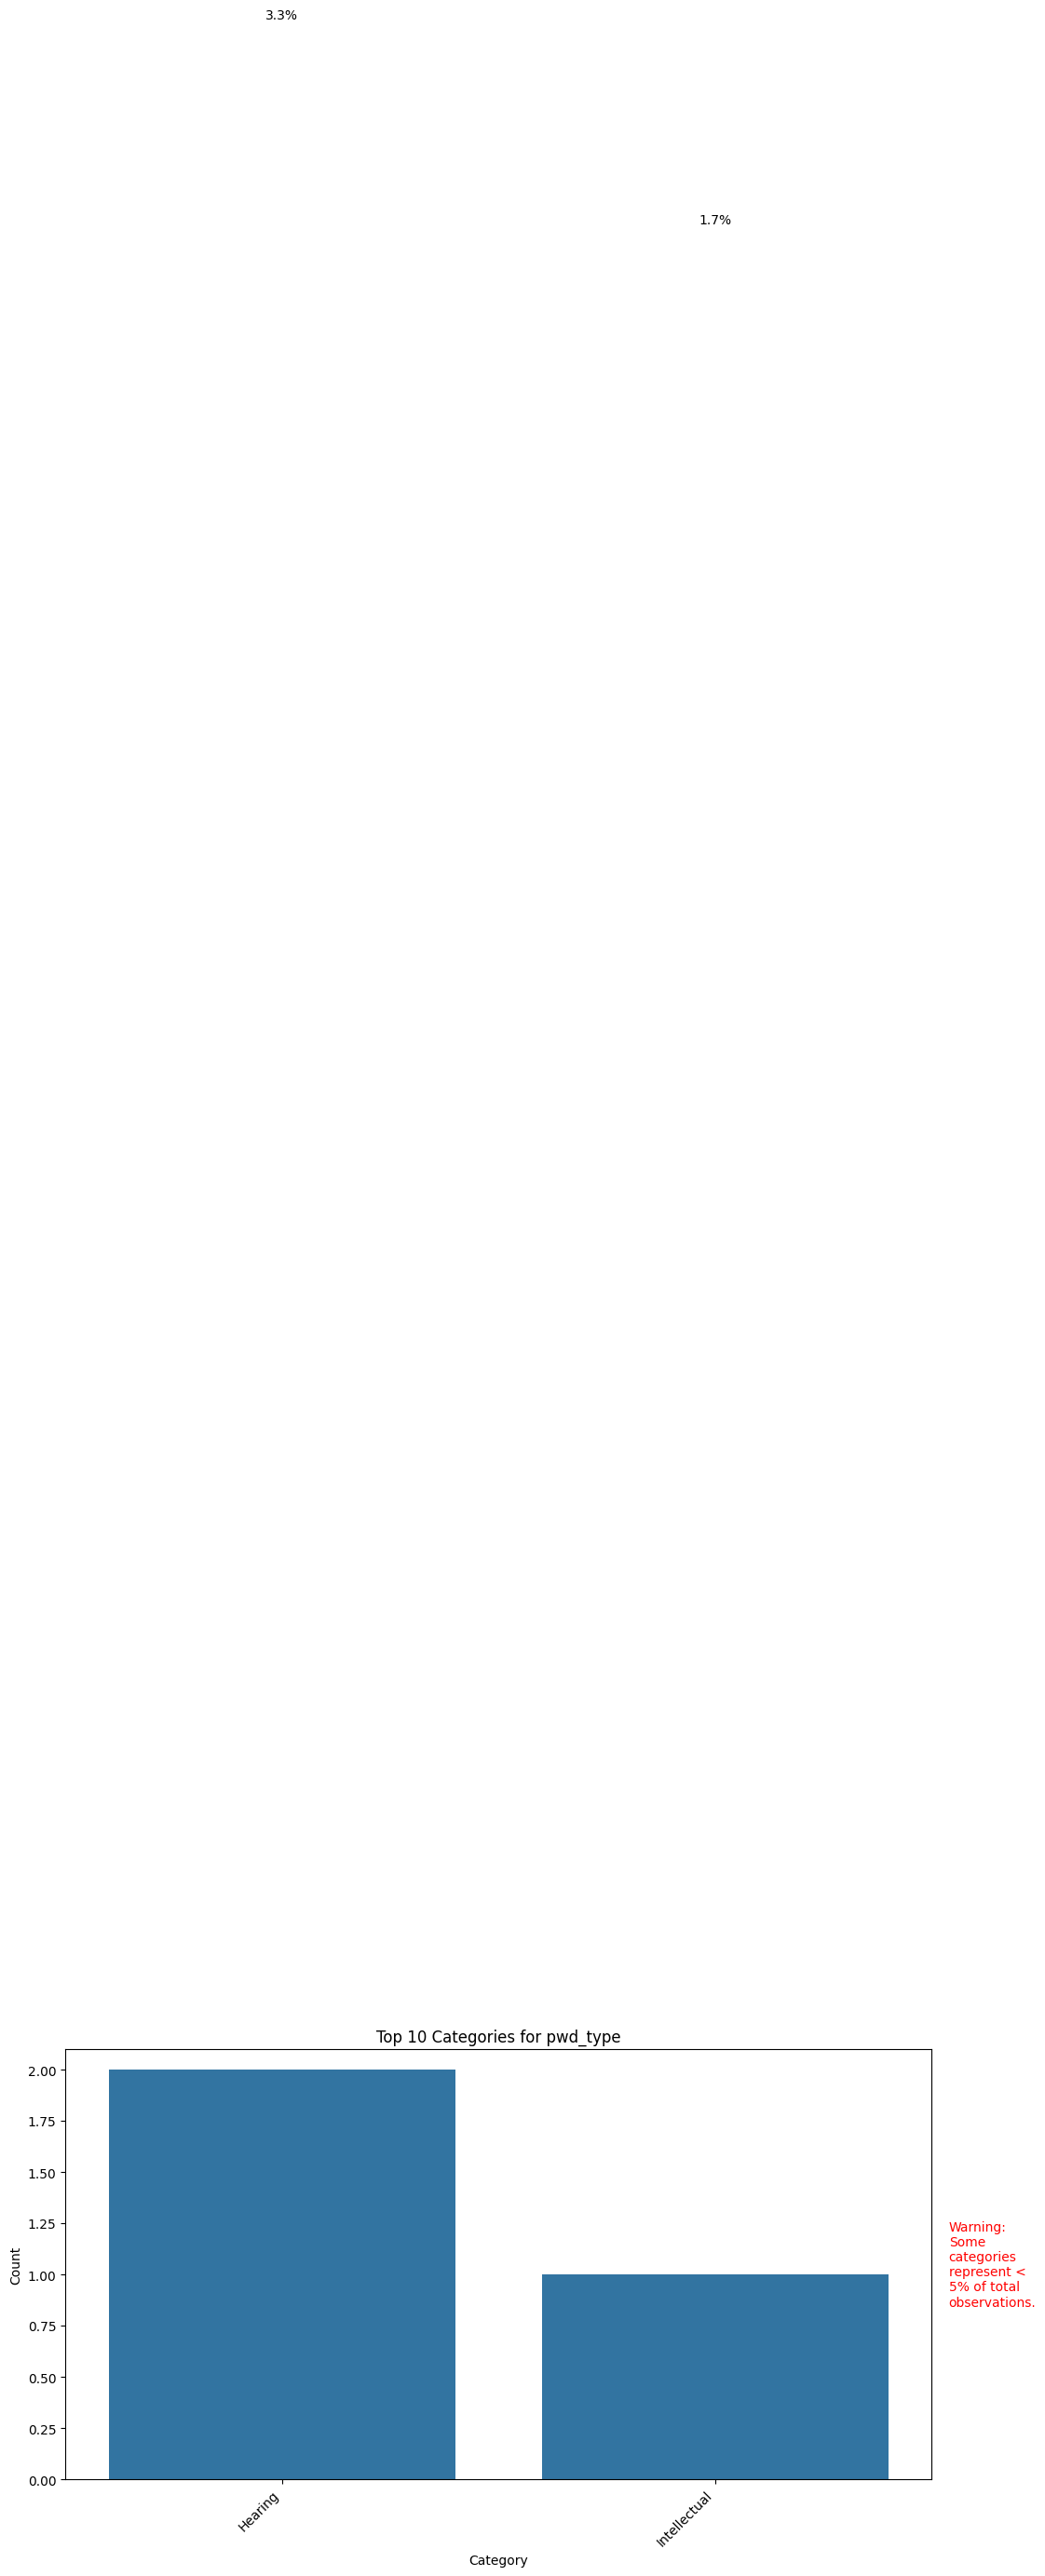

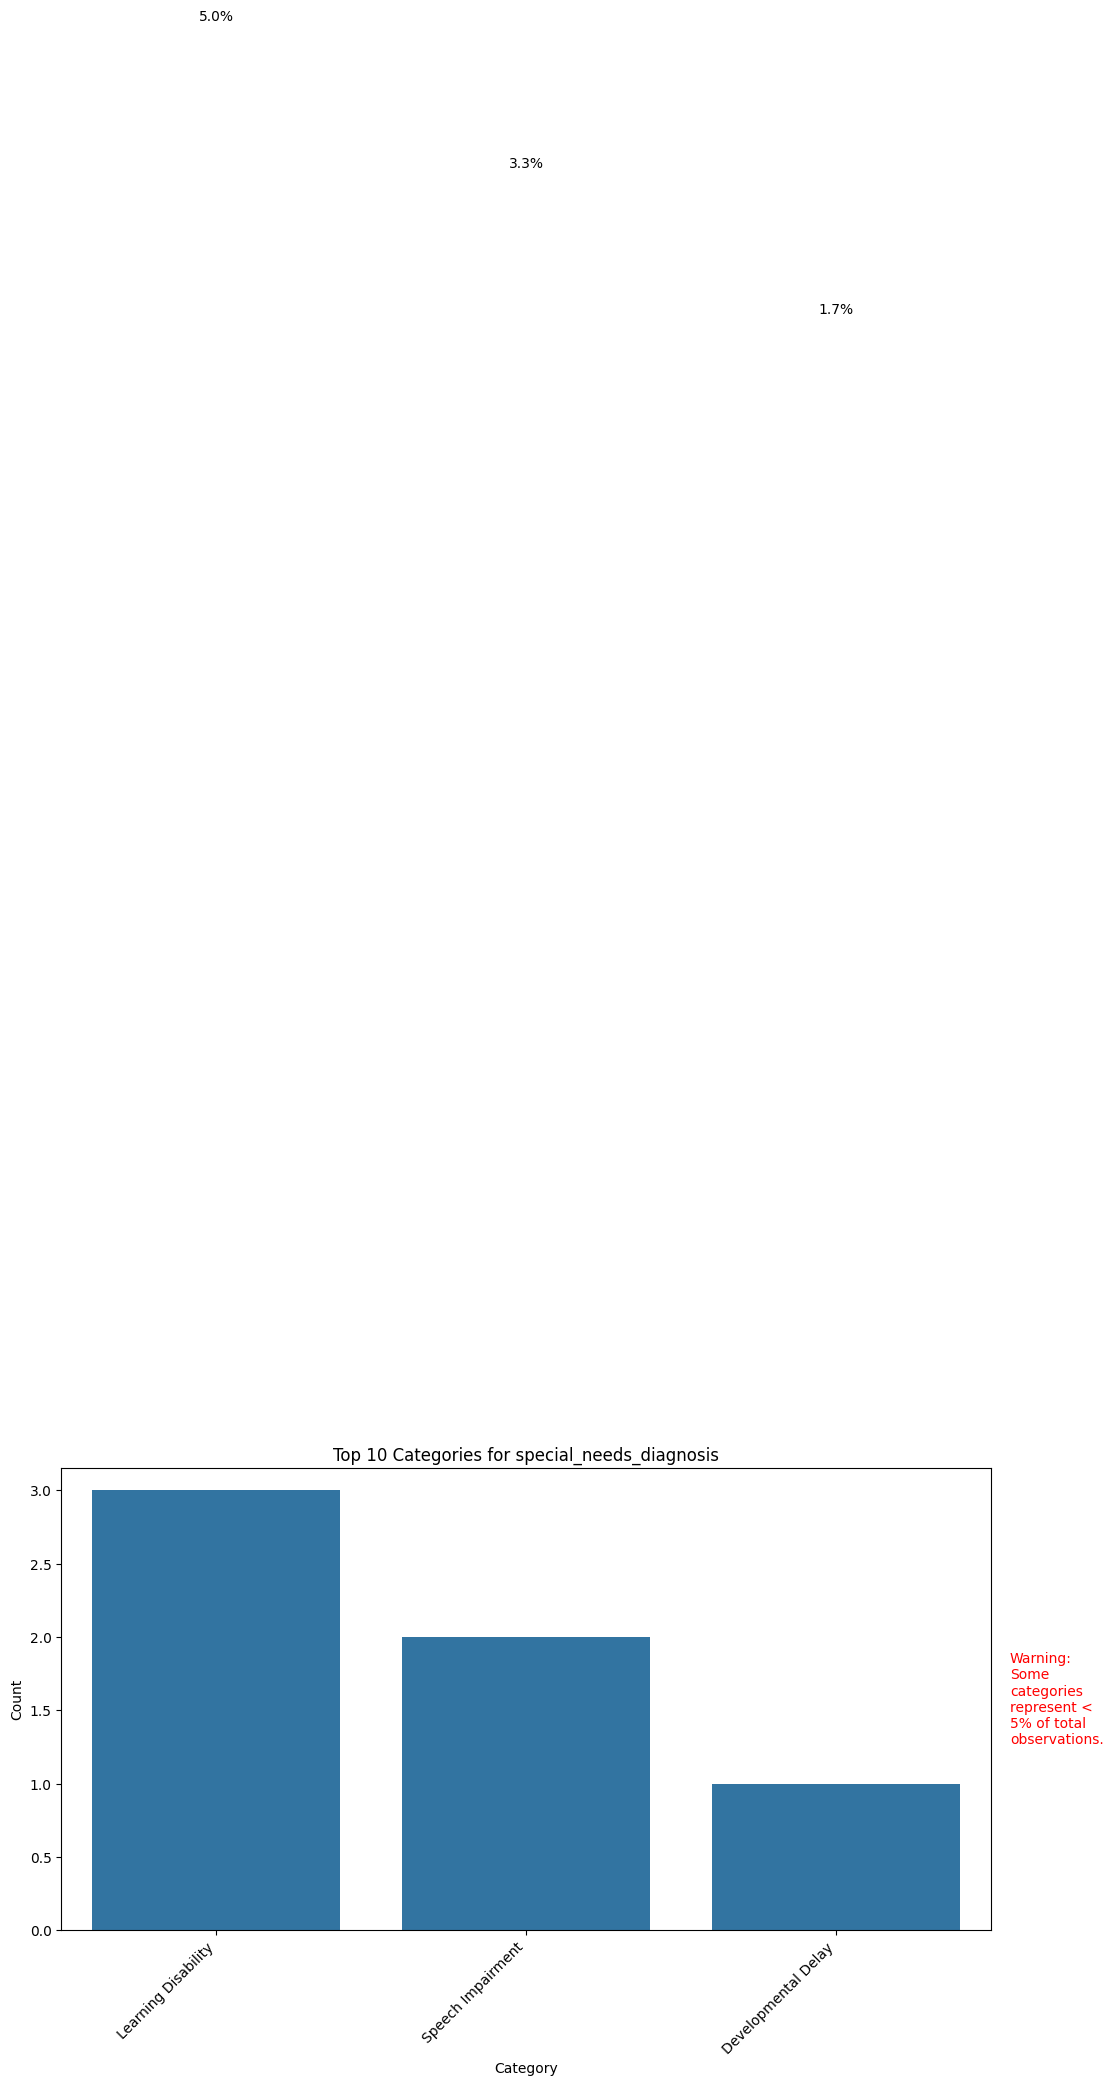

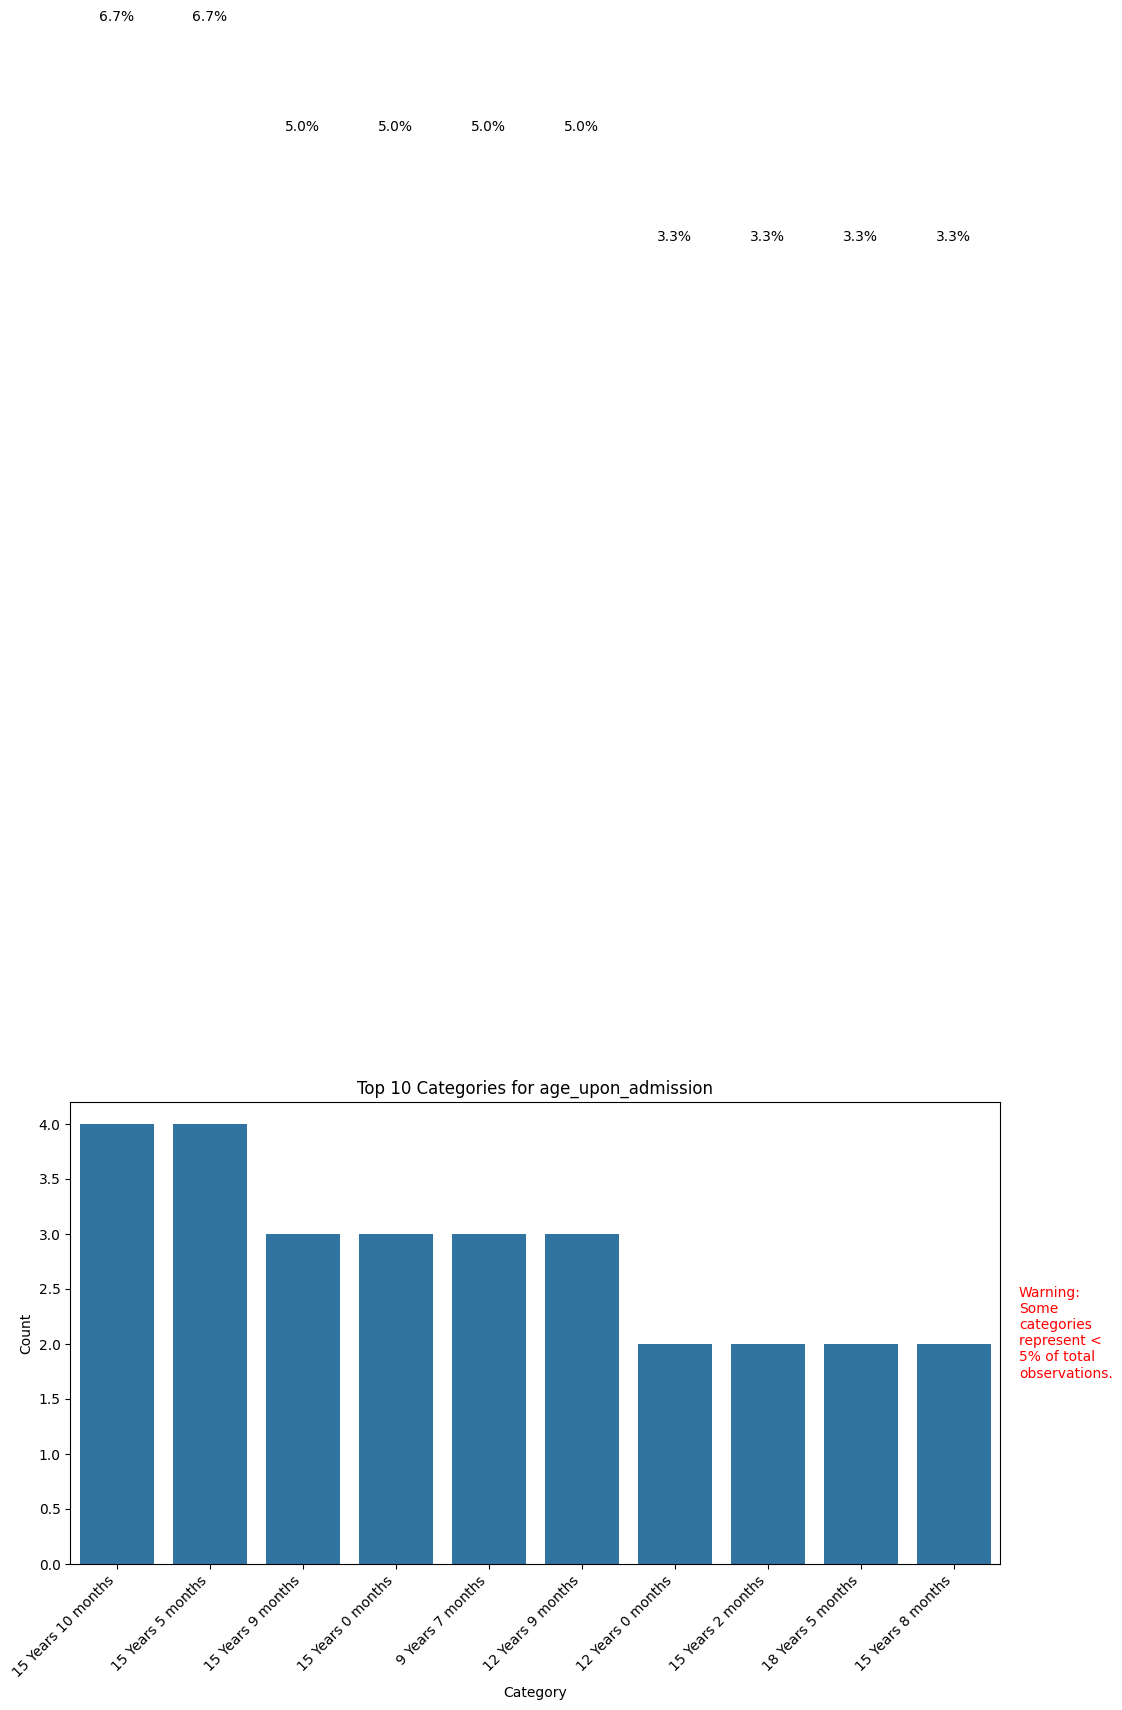

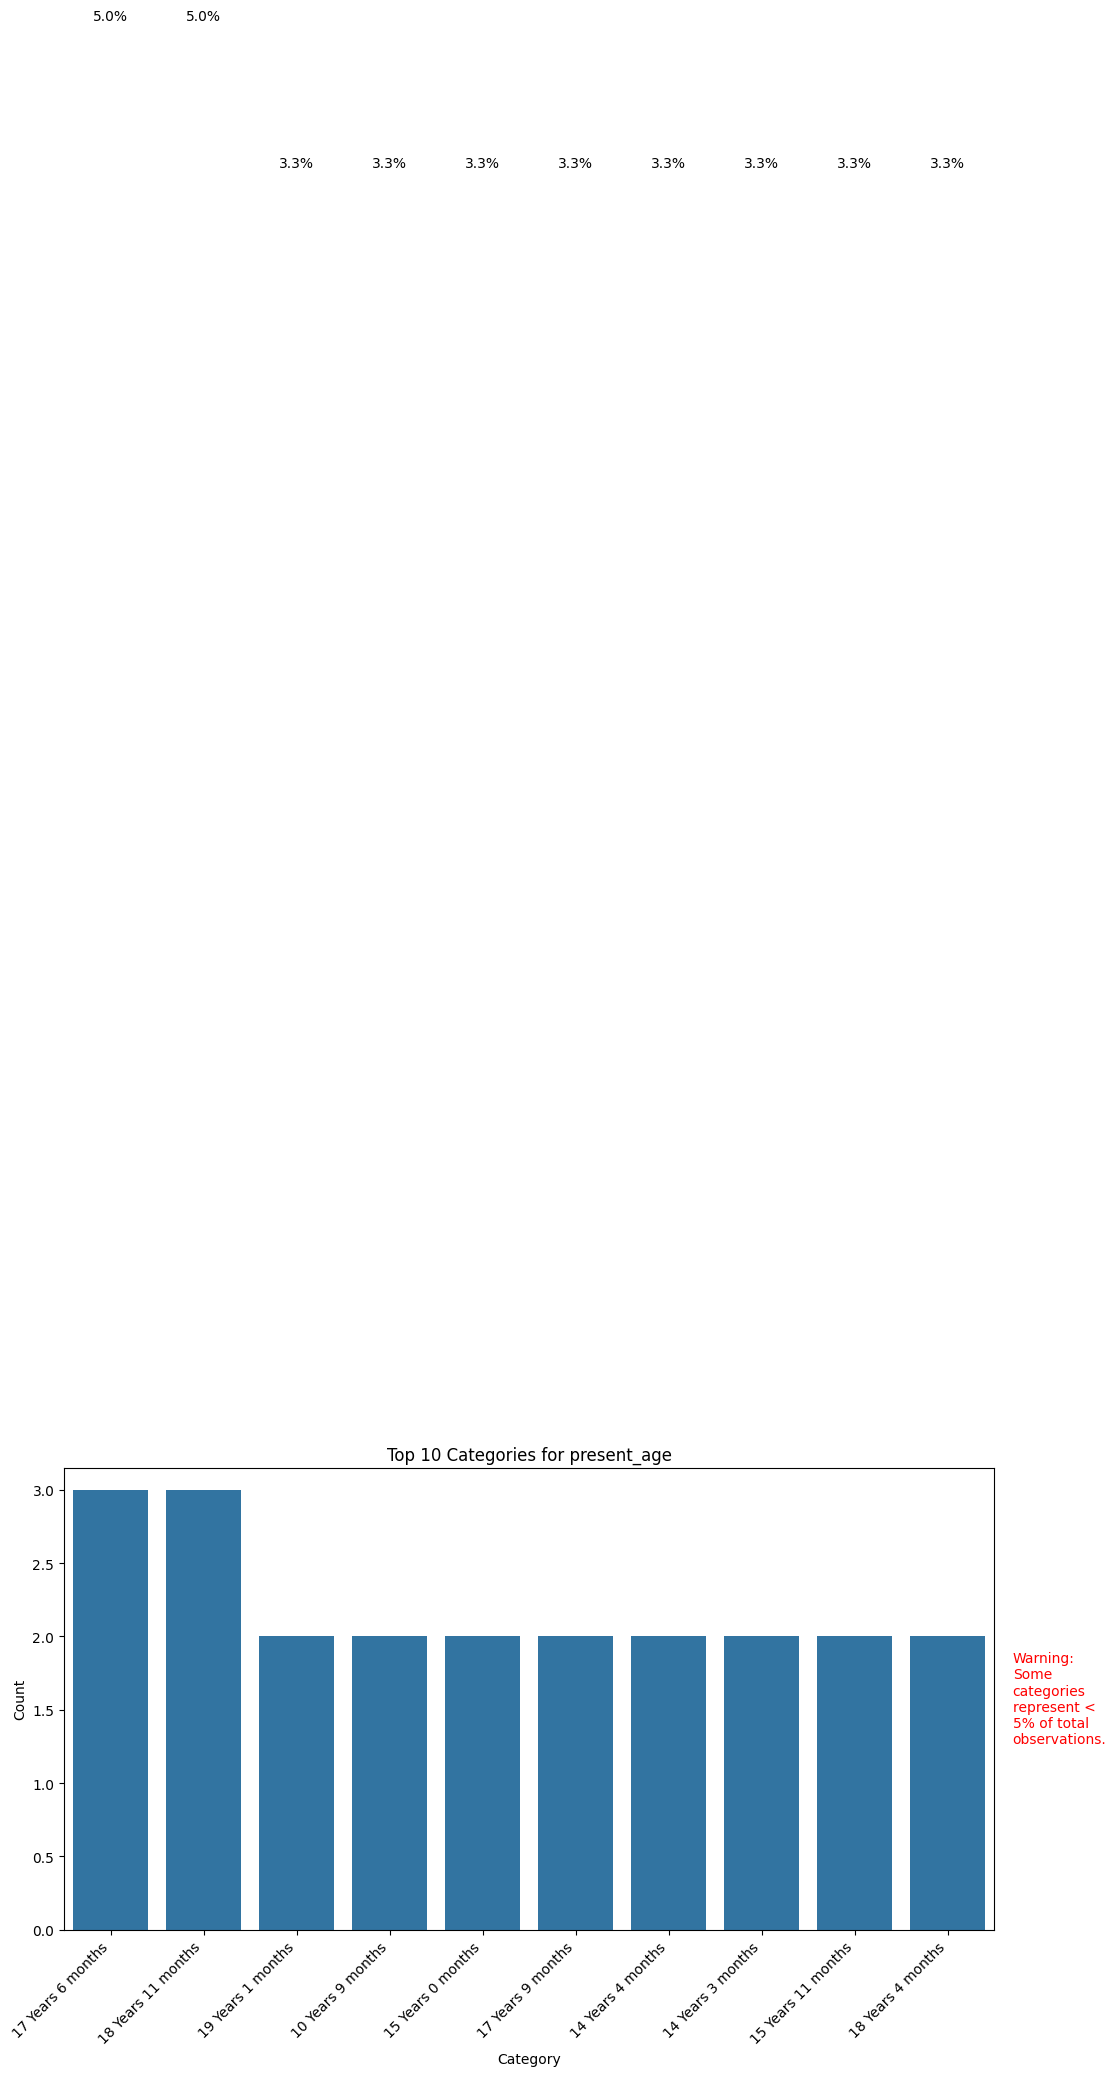

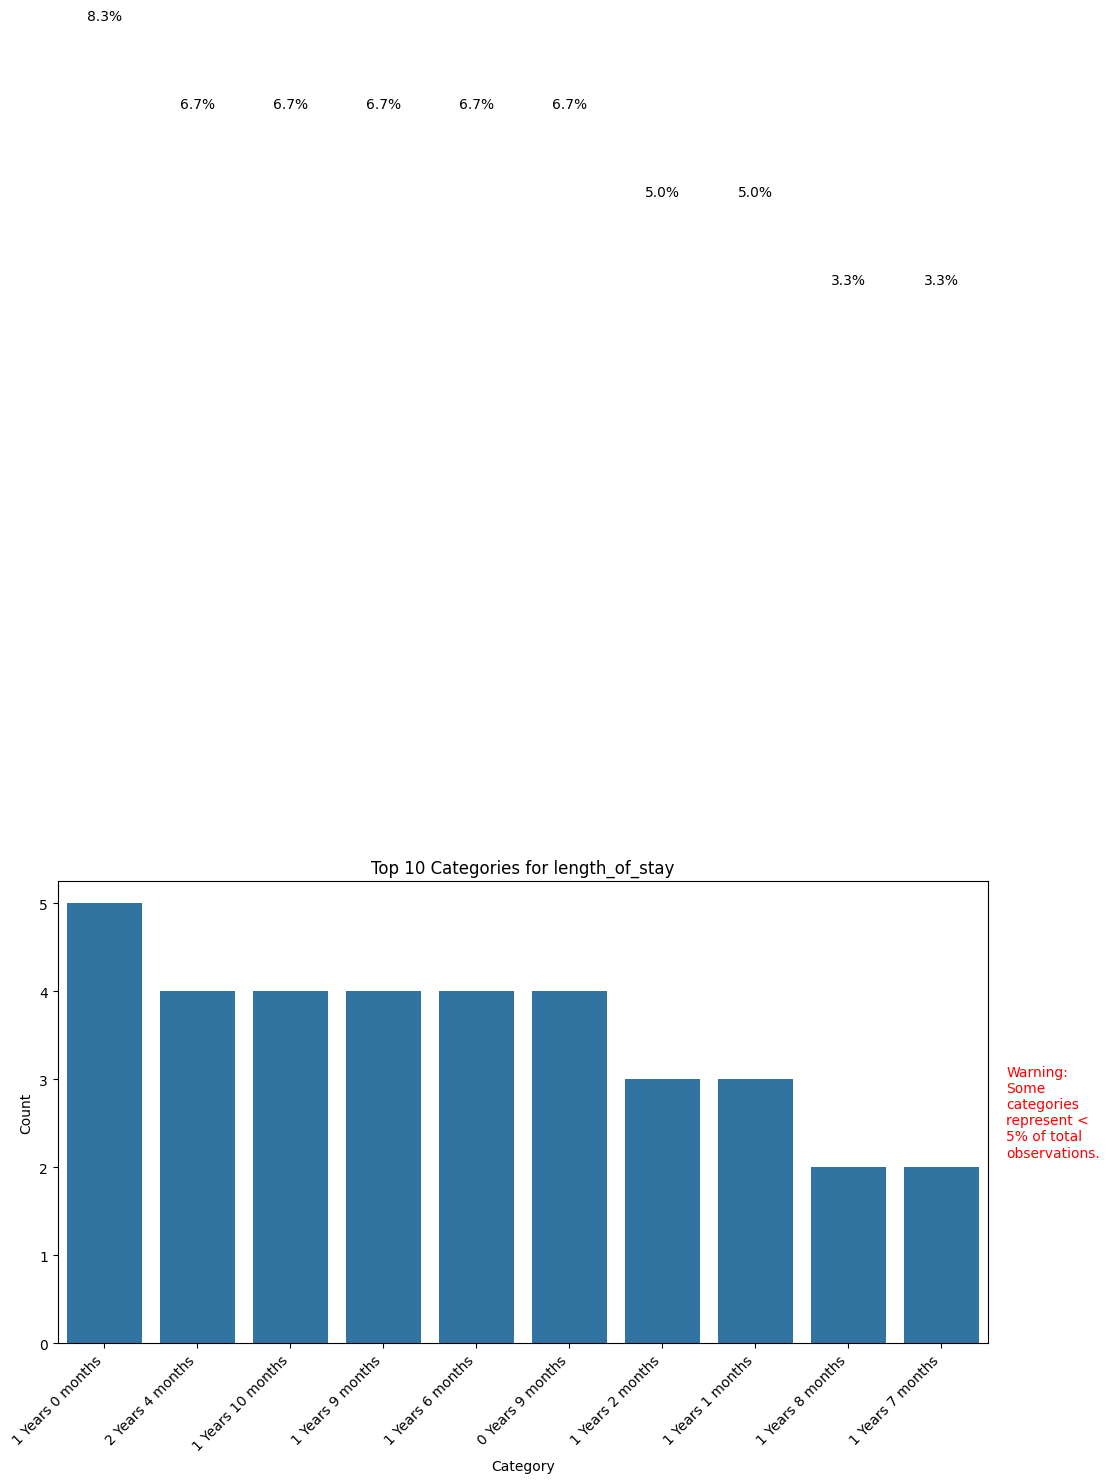

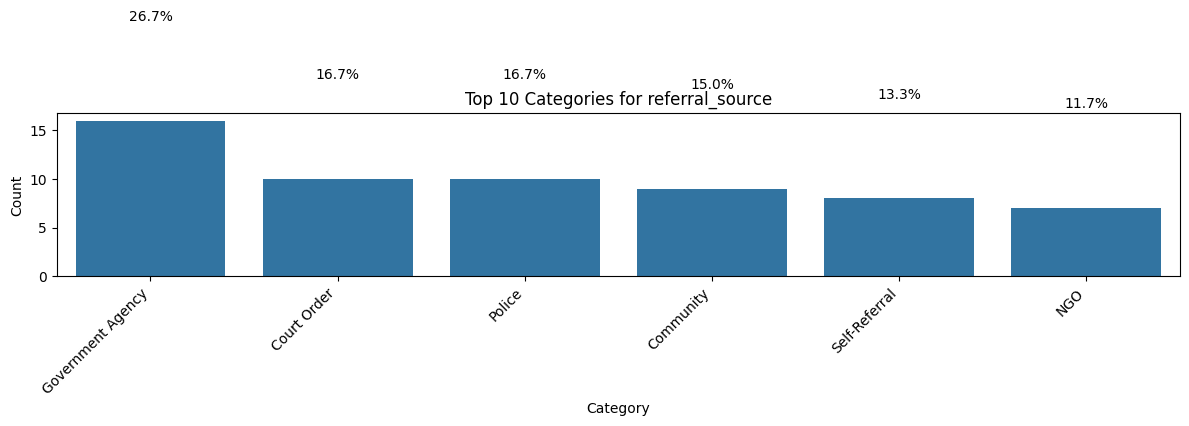

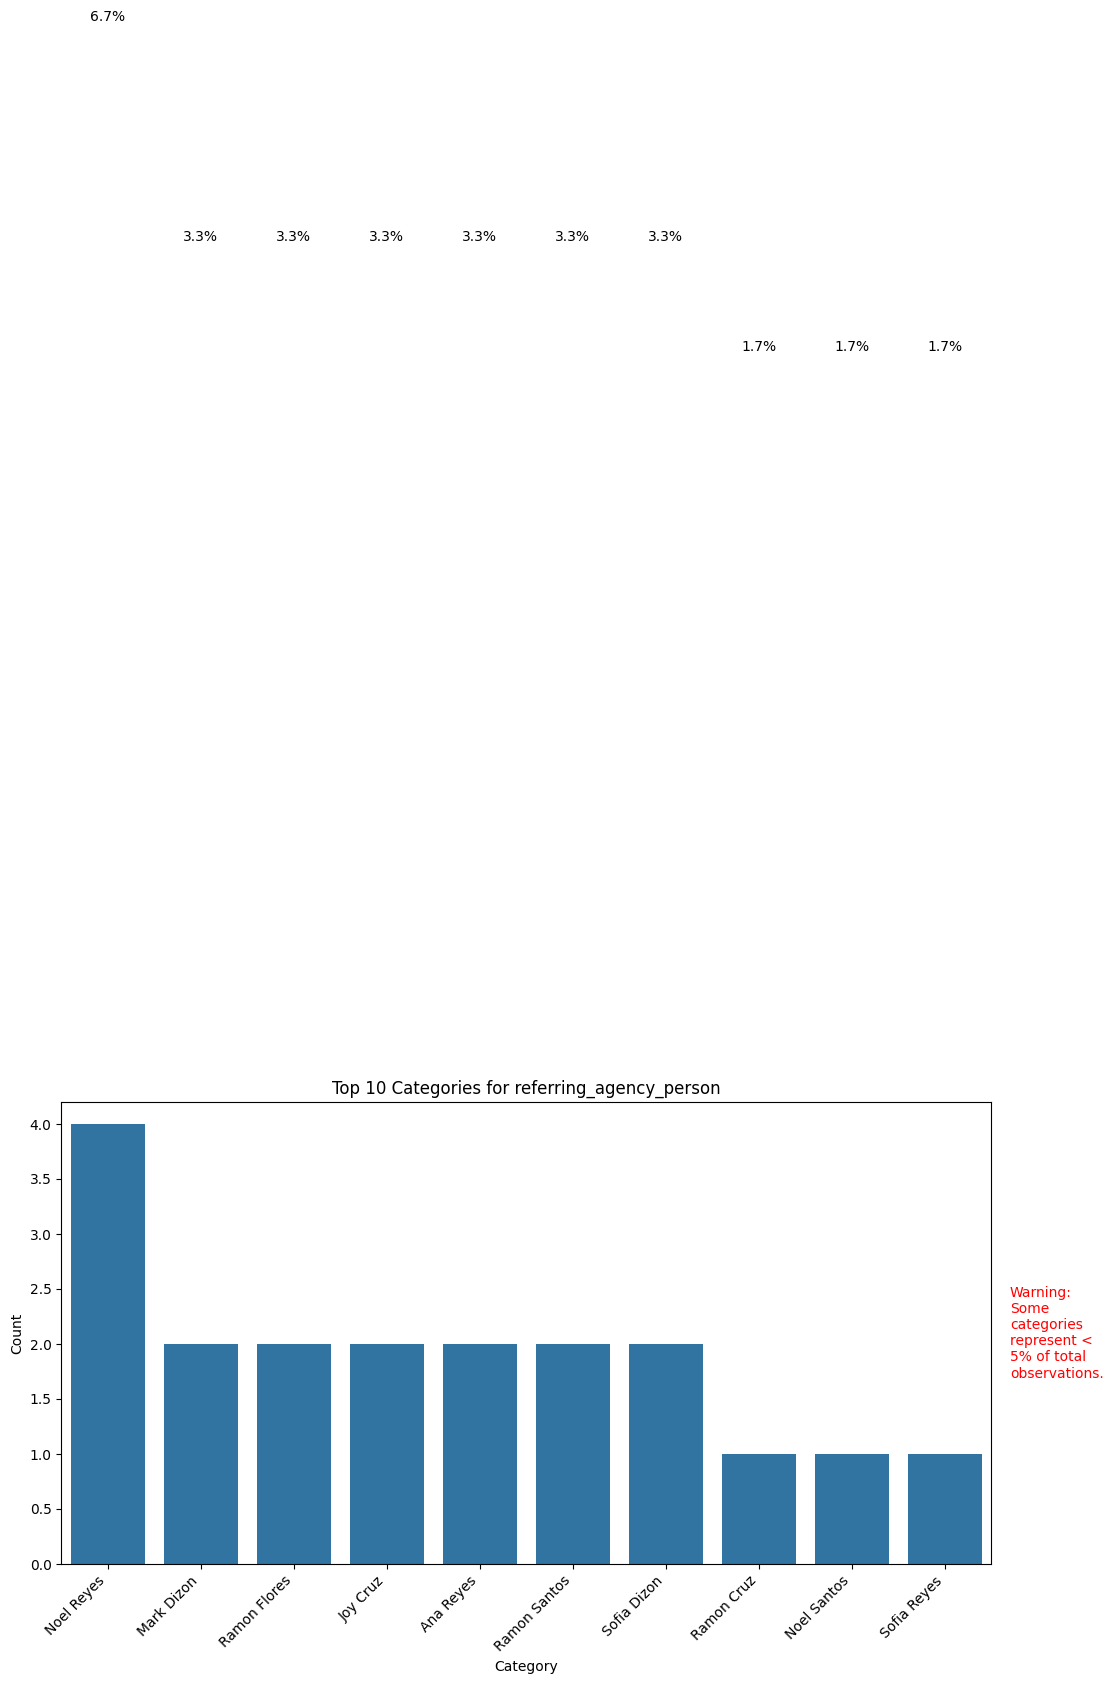

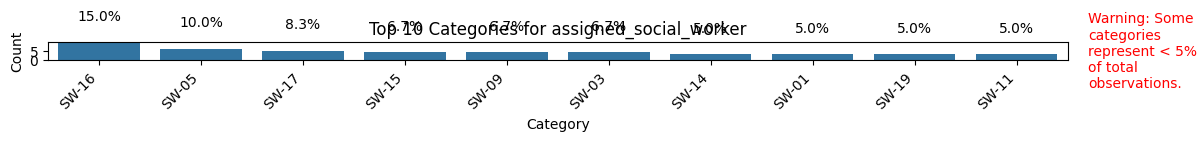

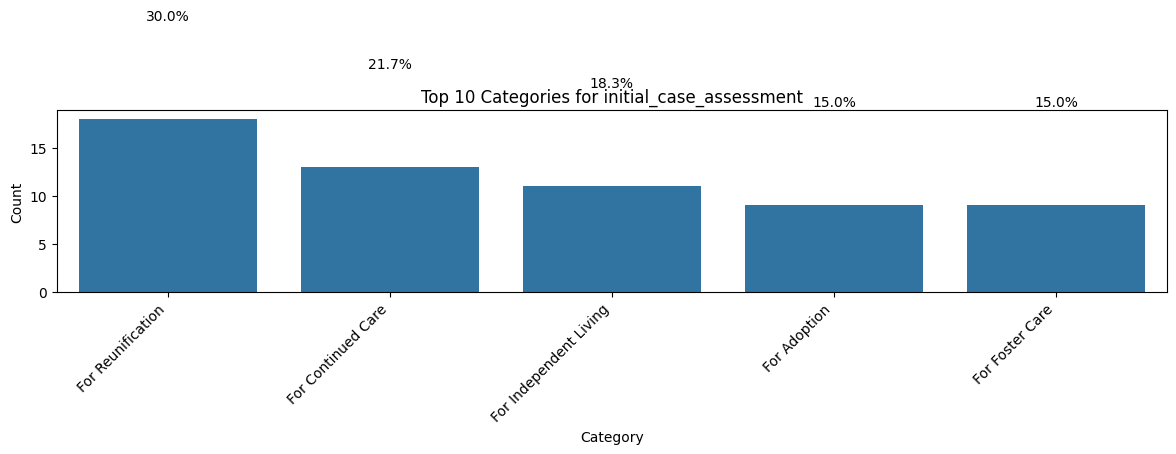

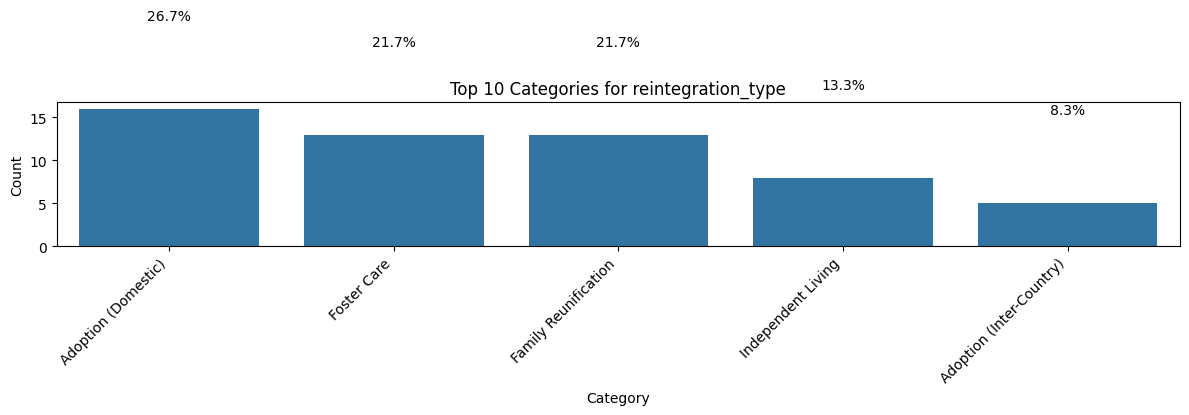

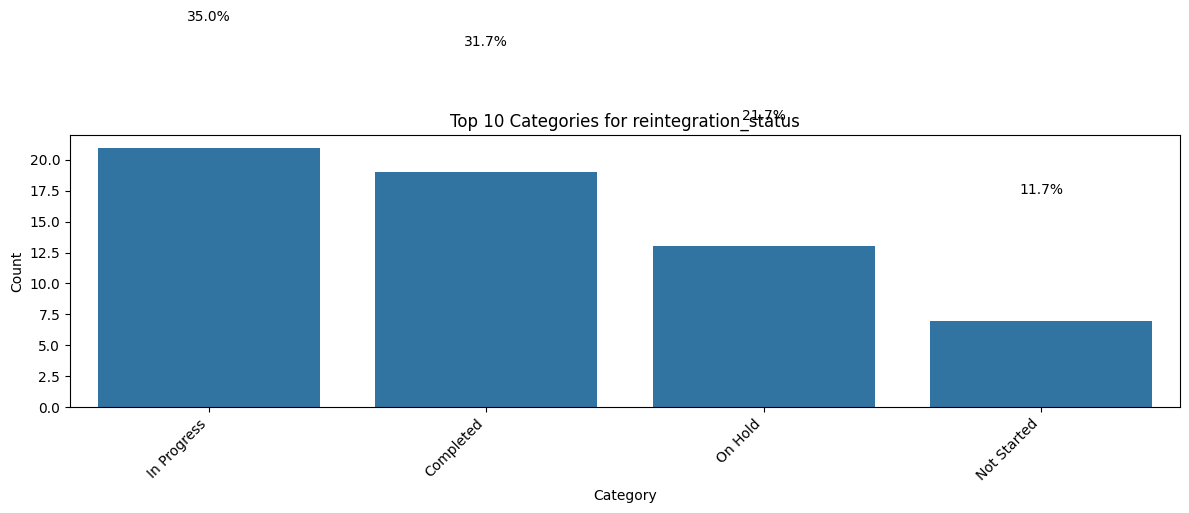

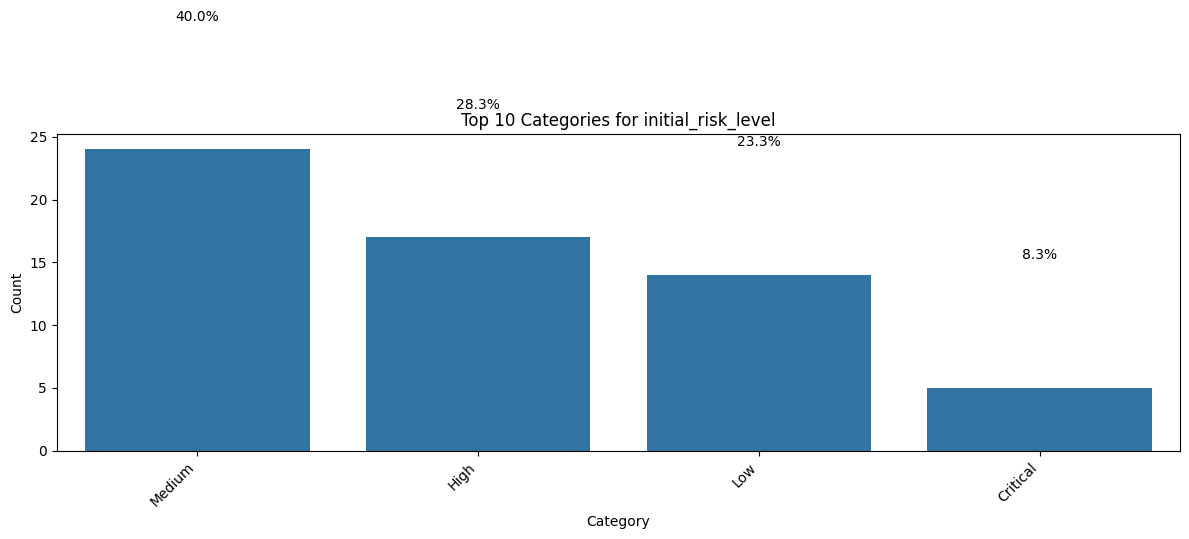

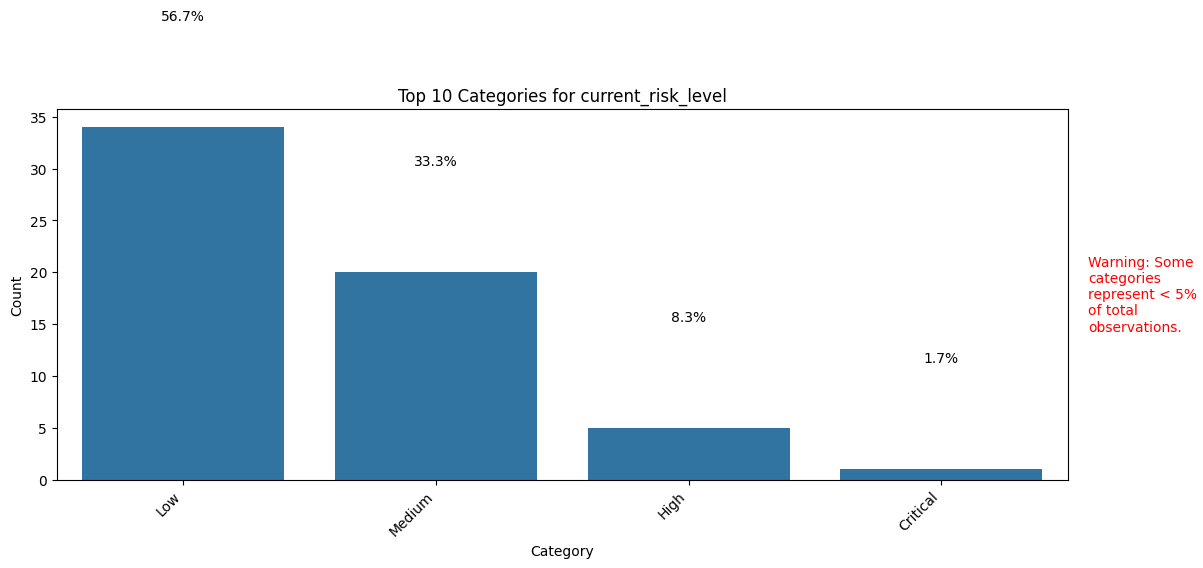

,Data Type,Count,Missing,Unique,Mode,Min,Q1,Median,Q3,Max,Mean,Std,Skew,Kurt
resident_id,int64,60,0,60,1,1,15.75,30.5,45.25,60,30.5,17.464249,0.0,-1.2
case_control_no,object,60,0,60,C0043,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
internal_code,object,60,0,60,LS-0001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
safehouse_id,int64,60,0,9,1,1,2.0,4.0,7.0,9,4.35,2.489469,0.191486,-1.224455
case_status,object,60,0,3,Active,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,object,60,0,1,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_of_birth,datetime64[ns],60,0,57,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
birth_status,object,60,0,2,Marital,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
place_of_birth,object,60,0,14,Davao City,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
religion,object,60,0,8,Evangelical,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
print("=" * 60)
print("UNIVARIATE — residents")
print("=" * 60)
res_uni = univariate(residents)
res_uni

UNIVARIATE — incident_reports


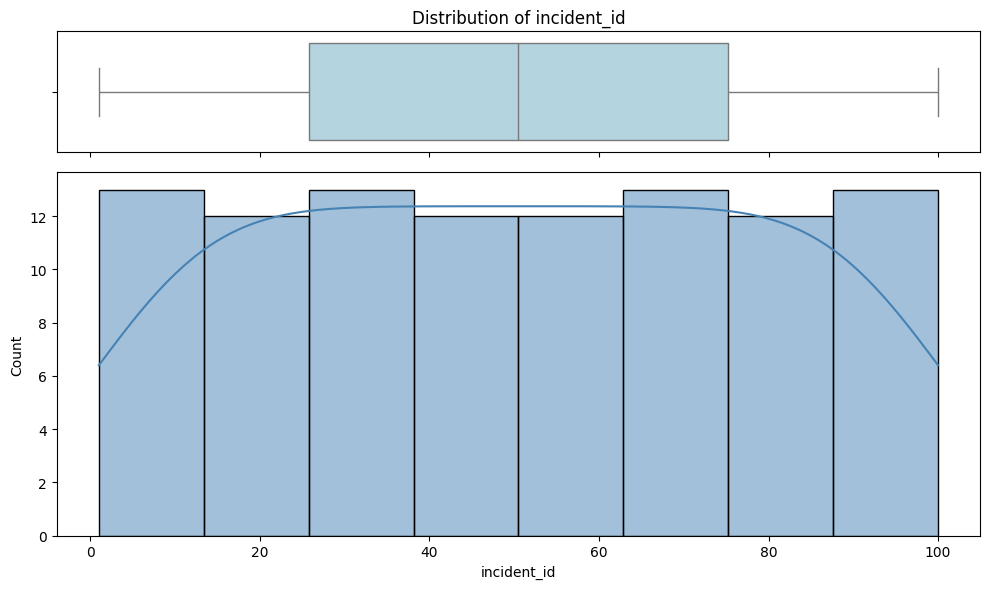

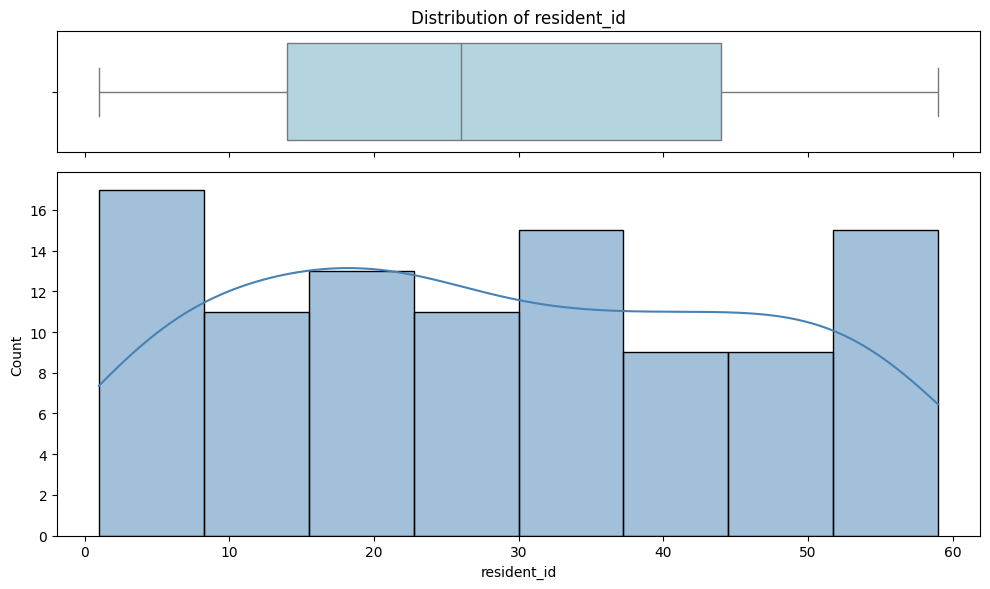

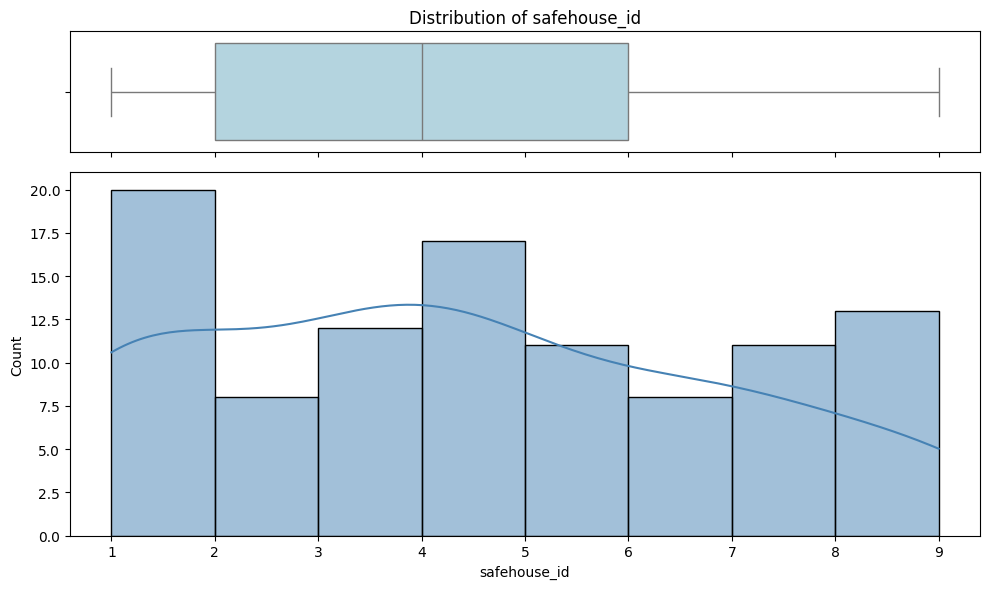

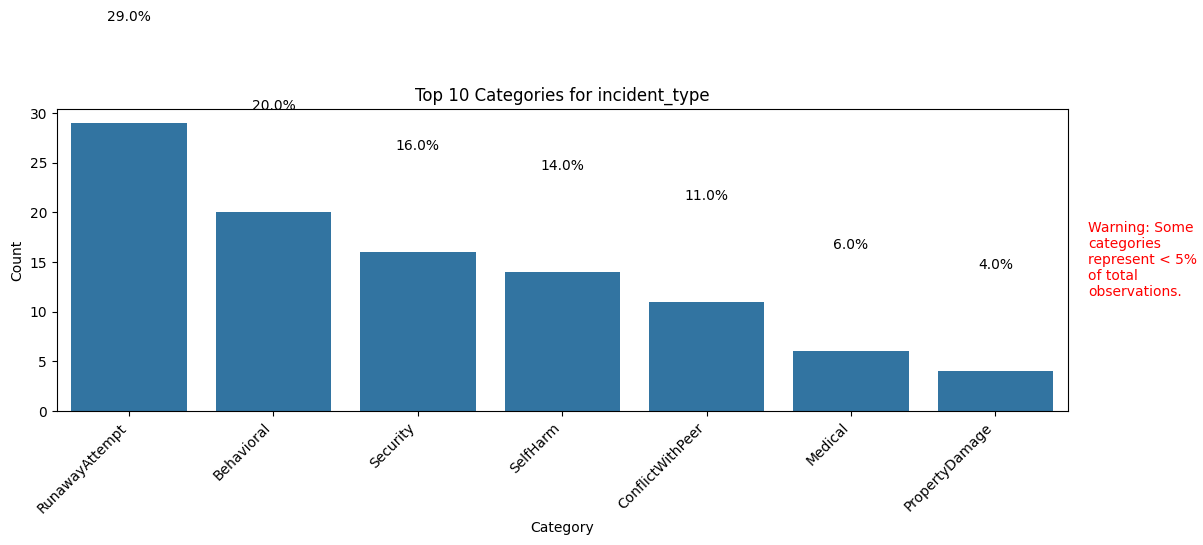

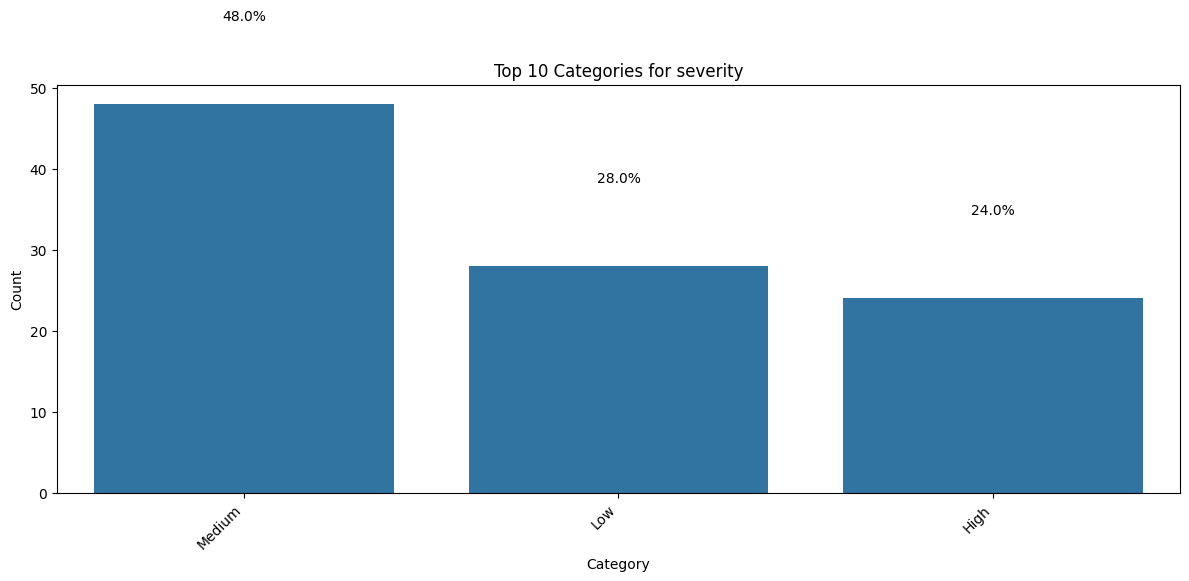

Column 'description' has too many unique values (100) for plotting. Skipping visualization.


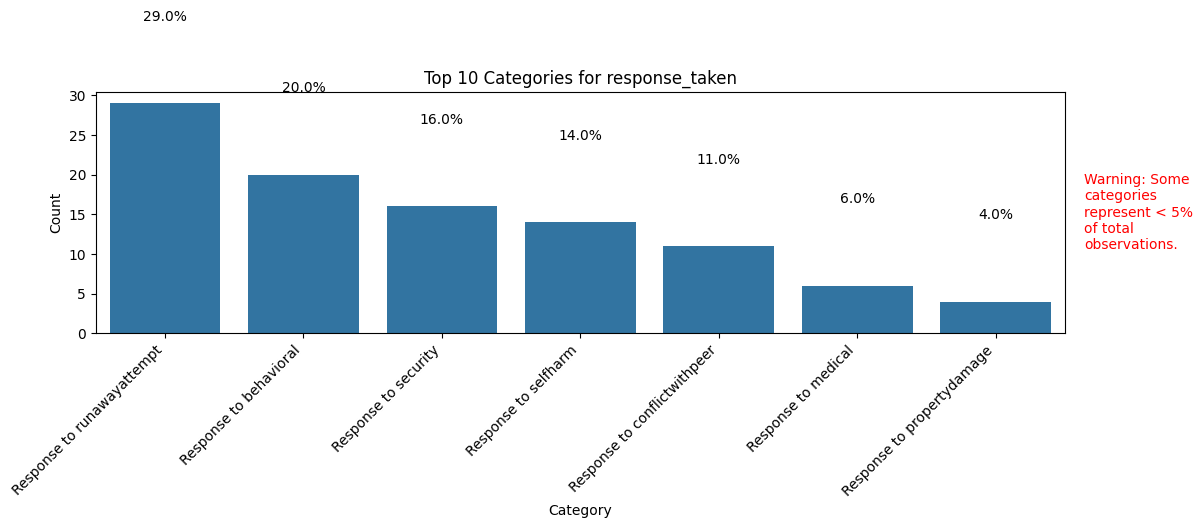

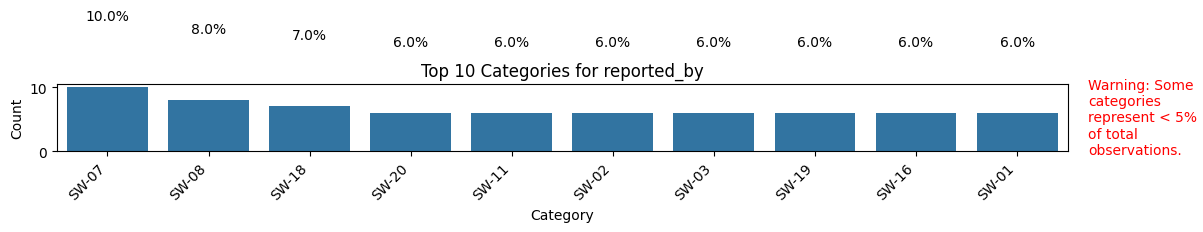

,Data Type,Count,Missing,Unique,Mode,Min,Q1,Median,Q3,Max,Mean,Std,Skew,Kurt
incident_id,int64,100,0,100,1,1,25.75,50.5,75.25,100,50.5,29.011492,0.0,-1.2
resident_id,int64,100,0,44,17,1,14.0,26.0,44.0,59,28.83,17.534413,0.104854,-1.213368
safehouse_id,int64,100,0,9,1,1,2.0,4.0,6.0,9,4.32,2.534131,0.292862,-0.988683
incident_date,datetime64[ns],100,0,97,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
incident_type,object,100,0,7,RunawayAttempt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
severity,object,100,0,3,Medium,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,object,100,0,100,Behavioral incident reported on 2023-09-24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
response_taken,object,100,0,7,Response to runawayattempt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
resolved,bool,100,0,2,True,False,NaN,NaN,NaN,True,0.71,NaN,NaN,NaN
resolution_date,datetime64[ns],71,29,70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [28]:
print("=" * 60)
print("UNIVARIATE — incident_reports")
print("=" * 60)
inc_uni = univariate(incidents)
inc_uni

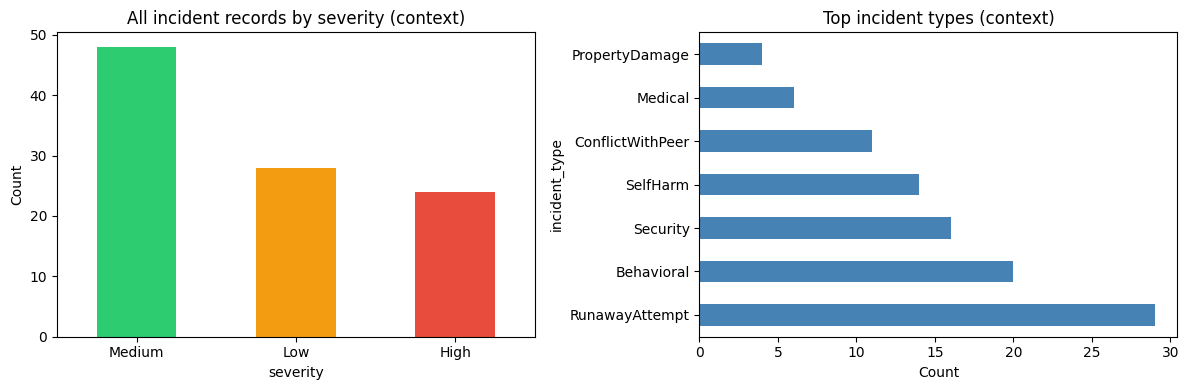


Incident rows: 100 total | High severity: 24 (24.0%)
Model target Y: ≥1 incident of ANY severity in (cutoff, cutoff + 30 days].


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

incidents['severity'].value_counts().plot.bar(ax=axes[0], color=['#2ecc71','#f39c12','#e74c3c'])
axes[0].set_title('All incident records by severity (context)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

incidents['incident_type'].value_counts().head(10).plot.barh(ax=axes[1], color='steelblue')
axes[1].set_title('Top incident types (context)')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

n_hi = (incidents['severity'] == 'High').sum()
print(f"\nIncident rows: {len(incidents)} total | High severity: {n_hi} ({100*n_hi/len(incidents):.1f}%)")
print("Model target Y: ≥1 incident of ANY severity in (cutoff, cutoff + 30 days].")

In [30]:
print("Date ranges per table:")
print("-" * 50)
date_cols = {
    'incidents': ('incident_date', incidents),
    'recordings': ('session_date', recordings),
    'education': ('record_date', education),
    'health': ('record_date', health),
    'visitations': ('visit_date', visitations),
    'interventions': ('target_date', interventions),
    'monthly_metrics': ('month_start', monthly_metrics),
}
for name, (col, tbl) in date_cols.items():
    mn, mx = tbl[col].min(), tbl[col].max()
    print(f"  {name:20s}  {str(mn)[:10]} → {str(mx)[:10]}")

print(f"\nResidents: admission {residents['date_of_admission'].min().date()} → {residents['date_of_admission'].max().date()}")
print(f"Residents with date_closed: {residents['date_closed'].notna().sum()} / {len(residents)}")

Date ranges per table:
--------------------------------------------------
  incidents             2023-04-08 → 2026-04-09
  recordings            2023-01-13 → 2027-02-02
  education             2023-01-01 → 2026-02-01
  health                2023-01-01 → 2026-02-01
  visitations           2023-02-23 → 2027-01-23
  interventions         2023-06-01 → 2026-01-01
  monthly_metrics       2023-01-01 → 2027-02-01

Residents: admission 2023-01-09 → 2025-04-06
Residents with date_closed: 30 / 60


**Observations from exploration:**
- Incidents vary by **severity** (Low / Medium / High) and **type**. The **binary target** is wider: **any** incident row in the forward 30-day window, which increases how often Y = 1 compared with “High only.”
- Date ranges determine how many monthly snapshot windows we can create. We need at least 30 days of forward data after each cutoff for the target definition.
- Most tables are keyed on `resident_id`, which links back to the `residents` table.

---

## Phase 3: Data Preparation (Ch. 2–5, 7)

### Build the Observation Table (Monthly Snapshots)

**Strategy:** For each 1st-of-month date in the data window, identify every resident who was **active** (admitted before cutoff and not yet closed). For each such resident-month pair:

- **Y = 1** if the resident has at least one `incident_reports` row with `incident_date` in `(cutoff, cutoff + 30 days]` — **any severity** (Low, Medium, or High)
- **Y = 0** otherwise

This generates many more training rows than the 60 residents (residents × months), giving us enough signal to train a classifier.

In [31]:
all_dates = pd.concat([
    incidents['incident_date'], recordings['session_date'],
    education['record_date'], health['record_date'],
    visitations['visit_date']
]).dropna()

data_start = all_dates.min()
data_end   = all_dates.max()

last_valid_cutoff = data_end - pd.Timedelta(days=30)
cutoffs = pd.date_range(
    start=pd.Timestamp(data_start.year, data_start.month, 1) + pd.DateOffset(months=1),
    end=last_valid_cutoff,
    freq='MS'
)

print(f"Data window: {data_start.date()} → {data_end.date()}")
print(f"Cutoff months: {len(cutoffs)} (first: {cutoffs[0].date()}, last: {cutoffs[-1].date()})")

rows = []
for cutoff in cutoffs:
    window_end = cutoff + pd.Timedelta(days=30)
    active = residents[
        (residents['date_of_admission'] <= cutoff) &
        ((residents['date_closed'].isna()) | (residents['date_closed'] > cutoff))
    ]
    for _, res in active.iterrows():
        rid = res['resident_id']
        has_any = incidents[
            (incidents['resident_id'] == rid) &
            (incidents['incident_date'] > cutoff) &
            (incidents['incident_date'] <= window_end)
        ].shape[0] > 0
        rows.append({'resident_id': rid, 'cutoff': cutoff, 'target': int(has_any)})

obs = pd.DataFrame(rows)
print(f"\nObservation table: {obs.shape[0]} rows  ({obs['target'].sum()} positive, {(obs['target']==0).sum()} negative)")
print(f"Target rate: {obs['target'].mean()*100:.1f}%")
obs.head(10)

Data window: 2023-01-01 → 2027-02-02
Cutoff months: 48 (first: 2023-02-01, last: 2027-01-01)

Observation table: 1446 rows  (91 positive, 1355 negative)
Target rate: 6.3%


,resident_id,cutoff,target
0,50,2023-02-01,0
1,13,2023-03-01,0
2,23,2023-03-01,0
3,45,2023-03-01,0
4,50,2023-03-01,0
5,2,2023-04-01,0
6,11,2023-04-01,0
7,13,2023-04-01,0
8,23,2023-04-01,0
9,29,2023-04-01,0


### Feature Engineering (Ch. 7)

For every (resident, cutoff) row, engineer features from **data strictly before the cutoff** to prevent data leakage.

**Feature families:**
- **A. Static / slow-changing** (from `residents`): case category, sub-category flags, family flags, disabilities, initial risk, referral source, tenure days
- **B. Counseling** (`process_recordings`): session counts (30d / 90d), mean duration, concern/progress/referral rates
- **C. Education** (`education_records`): mean attendance, mean progress, progress slope
- **D. Health** (`health_wellbeing_records`): mean scores for health, nutrition, sleep, energy; psych checkup rate
- **E. Home visitations** (`home_visitations`): visit count, safety concern rate, worst family cooperation
- **F. Interventions** (`intervention_plans`): open plans, overdue plans, plan category counts
- **G. Prior incidents** (`incident_reports`): count of prior **high-severity** incidents and **total** prior incidents (lookback only — still useful even though Y is now any severity)
- **H. Safehouse context** (`safehouses`, `safehouse_monthly_metrics`): region, capacity utilization, house-level metrics

In [32]:
coop_map = {'Excellent': 4, 'Good': 3, 'Fair': 2, 'Poor': 1}

def engineer_features(obs_df, residents, recordings, education, health,
                      visitations, interventions, incidents, safehouses, monthly_metrics):
    """Build feature columns for each (resident_id, cutoff) observation row."""
    feat_rows = []

    res_lookup = residents.set_index('resident_id')
    sh_lookup  = safehouses.set_index('safehouse_id')

    for _, row in obs_df.iterrows():
        rid    = row['resident_id']
        cutoff = row['cutoff']
        f = {}

        # --- A. Static / slow-changing from residents ---
        r = res_lookup.loc[rid]
        f['case_category']    = r.get('case_category', np.nan)
        for sc in ['sub_cat_orphaned','sub_cat_trafficked','sub_cat_child_labor',
                    'sub_cat_physical_abuse','sub_cat_sexual_abuse','sub_cat_osaec',
                    'sub_cat_cicl','sub_cat_at_risk','sub_cat_street_child','sub_cat_child_with_hiv']:
            f[sc] = int(r.get(sc, 0)) if pd.notna(r.get(sc, np.nan)) else 0
        f['is_pwd']             = int(r.get('is_pwd', 0)) if pd.notna(r.get('is_pwd', np.nan)) else 0
        f['has_special_needs']  = int(r.get('has_special_needs', 0)) if pd.notna(r.get('has_special_needs', np.nan)) else 0
        for ff in ['family_is_4ps','family_solo_parent','family_indigenous',
                    'family_parent_pwd','family_informal_settler']:
            f[ff] = int(r.get(ff, 0)) if pd.notna(r.get(ff, np.nan)) else 0
        f['initial_risk_level'] = r.get('initial_risk_level', np.nan)
        f['referral_source']    = r.get('referral_source', np.nan)
        adm = r.get('date_of_admission', pd.NaT)
        f['tenure_days'] = (cutoff - adm).days if pd.notna(adm) else np.nan

        # --- B. Counseling (process_recordings) ---
        rec_before = recordings[(recordings['resident_id'] == rid) & (recordings['session_date'] < cutoff)]
        rec_30  = rec_before[rec_before['session_date'] >= cutoff - pd.Timedelta(days=30)]
        rec_90  = rec_before[rec_before['session_date'] >= cutoff - pd.Timedelta(days=90)]
        f['sessions_30d']        = len(rec_30)
        f['sessions_90d']        = len(rec_90)
        f['mean_session_duration'] = rec_before['session_duration_minutes'].mean() if len(rec_before) > 0 else np.nan
        f['concerns_rate']       = rec_before['concerns_flagged'].mean() if len(rec_before) > 0 else np.nan
        f['progress_rate']       = rec_before['progress_noted'].mean() if len(rec_before) > 0 else np.nan
        f['referral_rate']       = rec_before['referral_made'].mean() if len(rec_before) > 0 else np.nan

        # --- C. Education (education_records) ---
        edu_before = education[(education['resident_id'] == rid) & (education['record_date'] < cutoff)]
        f['mean_attendance'] = edu_before['attendance_rate'].mean() if len(edu_before) > 0 else np.nan
        f['mean_progress']   = edu_before['progress_percent'].mean() if len(edu_before) > 0 else np.nan
        if len(edu_before) >= 3:
            vals = edu_before.sort_values('record_date')['progress_percent'].values
            x = np.arange(len(vals))
            f['progress_slope'] = float(np.polyfit(x, vals, 1)[0])
        else:
            f['progress_slope'] = np.nan

        # --- D. Health (health_wellbeing_records) ---
        hlth_before = health[(health['resident_id'] == rid) & (health['record_date'] < cutoff)]
        f['mean_health']    = hlth_before['general_health_score'].mean() if len(hlth_before) > 0 else np.nan
        f['mean_nutrition'] = hlth_before['nutrition_score'].mean() if len(hlth_before) > 0 else np.nan
        f['mean_sleep']     = hlth_before['sleep_quality_score'].mean() if len(hlth_before) > 0 else np.nan
        f['mean_energy']    = hlth_before['energy_level_score'].mean() if len(hlth_before) > 0 else np.nan
        f['psych_checkup_rate'] = hlth_before['psychological_checkup_done'].mean() if len(hlth_before) > 0 else np.nan

        # --- E. Home visitations ---
        vis_before = visitations[(visitations['resident_id'] == rid) & (visitations['visit_date'] < cutoff)]
        f['visit_count']        = len(vis_before)
        f['safety_concern_rate'] = vis_before['safety_concerns_noted'].mean() if len(vis_before) > 0 else np.nan
        if len(vis_before) > 0 and 'family_cooperation_level' in vis_before.columns:
            mapped = vis_before['family_cooperation_level'].map(coop_map)
            f['worst_cooperation'] = mapped.min() if mapped.notna().any() else np.nan
        else:
            f['worst_cooperation'] = np.nan

        # --- F. Interventions ---
        int_before = interventions[(interventions['resident_id'] == rid)]
        int_before = int_before[int_before['created_at'] < cutoff] if 'created_at' in int_before.columns else int_before
        f['open_plans']    = int_before[int_before['status'].isin(['Open','In Progress'])].shape[0]
        f['overdue_plans'] = int_before[
            (int_before['target_date'] < cutoff) &
            (~int_before['status'].isin(['Achieved','Closed']))
        ].shape[0]
        for cat in ['Safety','Psychosocial','Education','Health','Livelihood']:
            f[f'plans_{cat.lower()}'] = int_before[int_before['plan_category'] == cat].shape[0]

        # --- G. Prior incidents (lookback ONLY — not in target window) ---
        inc_before = incidents[(incidents['resident_id'] == rid) & (incidents['incident_date'] < cutoff)]
        f['prior_incident_count'] = len(inc_before)
        f['prior_high_incidents'] = (inc_before['severity'] == 'High').sum()

        # --- H. Safehouse context ---
        sh_id = r.get('safehouse_id', np.nan)
        if pd.notna(sh_id) and sh_id in sh_lookup.index:
            sh = sh_lookup.loc[sh_id]
            f['sh_region'] = sh.get('region', np.nan)
            cap = sh.get('capacity_girls', np.nan)
            occ = sh.get('current_occupancy', np.nan)
            f['sh_utilization'] = occ / cap if pd.notna(cap) and cap > 0 else np.nan
        else:
            f['sh_region'] = np.nan
            f['sh_utilization'] = np.nan

        prev_month = (cutoff - pd.DateOffset(months=1)).replace(day=1)
        mm = monthly_metrics[
            (monthly_metrics['safehouse_id'] == sh_id) &
            (monthly_metrics['month_start'] == prev_month)
        ]
        if len(mm) > 0:
            m = mm.iloc[0]
            f['sh_avg_edu_progress']  = m.get('avg_education_progress', np.nan)
            f['sh_avg_health_score']  = m.get('avg_health_score', np.nan)
            f['sh_incident_count']    = m.get('incident_count', np.nan)
        else:
            f['sh_avg_edu_progress'] = np.nan
            f['sh_avg_health_score'] = np.nan
            f['sh_incident_count']   = np.nan

        feat_rows.append(f)

    feat_df = pd.DataFrame(feat_rows, index=obs_df.index)
    return pd.concat([obs_df, feat_df], axis=1)

df = engineer_features(obs, residents, recordings, education, health,
                       visitations, interventions, incidents, safehouses, monthly_metrics)

print(f"Feature-engineered dataset: {df.shape[0]} rows × {df.shape[1]} cols")
print(f"Columns: {list(df.columns)}")
df.head()

Feature-engineered dataset: 1446 rows × 55 cols
Columns: ['resident_id', 'cutoff', 'target', 'case_category', 'sub_cat_orphaned', 'sub_cat_trafficked', 'sub_cat_child_labor', 'sub_cat_physical_abuse', 'sub_cat_sexual_abuse', 'sub_cat_osaec', 'sub_cat_cicl', 'sub_cat_at_risk', 'sub_cat_street_child', 'sub_cat_child_with_hiv', 'is_pwd', 'has_special_needs', 'family_is_4ps', 'family_solo_parent', 'family_indigenous', 'family_parent_pwd', 'family_informal_settler', 'initial_risk_level', 'referral_source', 'tenure_days', 'sessions_30d', 'sessions_90d', 'mean_session_duration', 'concerns_rate', 'progress_rate', 'referral_rate', 'mean_attendance', 'mean_progress', 'progress_slope', 'mean_health', 'mean_nutrition', 'mean_sleep', 'mean_energy', 'psych_checkup_rate', 'visit_count', 'safety_concern_rate', 'worst_cooperation', 'open_plans', 'overdue_plans', 'plans_safety', 'plans_psychosocial', 'plans_education', 'plans_health', 'plans_livelihood', 'prior_incident_count', 'prior_high_incidents', '

,resident_id,cutoff,target,case_category,sub_cat_orphaned,sub_cat_trafficked,sub_cat_child_labor,sub_cat_physical_abuse,sub_cat_sexual_abuse,sub_cat_osaec,...,plans_education,plans_health,plans_livelihood,prior_incident_count,prior_high_incidents,sh_region,sh_utilization,sh_avg_edu_progress,sh_avg_health_score,sh_incident_count
0,50,2023-02-01,0,Neglected,0,0,0,0,0,0,...,1,0,0,0,0,Visayas,1.000000,33.9,3.03,0
1,13,2023-03-01,0,Surrendered,0,0,1,0,0,0,...,1,0,0,0,0,Visayas,0.800000,43.6,3.19,0
2,23,2023-03-01,0,Foundling,0,0,0,0,1,0,...,1,0,0,0,0,Luzon,0.818182,50.0,3.12,0
3,45,2023-03-01,0,Abandoned,1,0,0,0,1,0,...,1,0,0,0,0,Mindanao,1.000000,64.7,3.04,0
4,50,2023-03-01,0,Neglected,0,0,0,0,0,0,...,1,0,0,0,0,Visayas,1.000000,45.9,3.17,0


### Data Preparation Pipeline (Ch. 7)

Apply the reusable utility functions from `function.py` to clean the engineered feature set:
1. **`basic_wrangling()`** — drop columns where every value is unique (IDs, free text)
2. **`bin_categories()`** — consolidate rare categories (< 5%) into "Other"
3. **`handle_missing_data()`** — report missingness patterns and drop columns/rows exceeding thresholds
4. **`normalize()`** — check skewness (informational; sklearn scaler handles it downstream)
5. **`manage_outliers()`** — detect outliers using DBSCAN (report only; do NOT drop — outliers may be risk signals)

In [33]:
# Keep `cutoff` through prep so we can do a temporal train/test split (Ch. 15); drop before modeling features.
id_cols = ['resident_id']
df_model = df.drop(columns=id_cols).copy()

# Parse before bin_categories: otherwise `cutoff` is object dtype and rare month strings become "Other".
df_model["cutoff"] = pd.to_datetime(df_model["cutoff"], errors="coerce")

print("Step 1: basic_wrangling — drop all-unique text columns")
before_cols = set(df_model.columns)
df_model = basic_wrangling(df_model)
dropped = before_cols - set(df_model.columns)
print(f"  Dropped: {dropped if dropped else 'none'}")

print("\nStep 2: bin_categories — consolidate rare categories into 'Other'")
df_model = bin_categories(df_model)
for col in df_model.select_dtypes(include='object').columns:
    print(f"  {col}: {df_model[col].value_counts().to_dict()}")

print("\nStep 3: handle_missing_data — report missingness")
df_model, missing_report = handle_missing_data(df_model, col_threshold=0.6, row_threshold=0.7)
print(f"  Dropped columns: {missing_report['dropped_columns']}")
print(f"  Dropped rows: {missing_report['dropped_rows']}")
print(f"  Remaining shape: {df_model.shape}")
if not missing_report['missing_summary'].empty:
    print(missing_report['missing_summary'][missing_report['missing_summary']['missing_count'] > 0])

Step 1: basic_wrangling — drop all-unique text columns
  Dropped: none

Step 2: bin_categories — consolidate rare categories into 'Other'
  case_category: {'Surrendered': 564, 'Abandoned': 344, 'Neglected': 270, 'Foundling': 268}
  initial_risk_level: {'Medium': 508, 'High': 478, 'Low': 339, 'Critical': 121}
  referral_source: {'Government Agency': 360, 'Police': 249, 'Court Order': 235, 'Community': 229, 'NGO': 194, 'Self-Referral': 179}
  sh_region: {'Visayas': 684, 'Luzon': 441, 'Mindanao': 321}

Step 3: handle_missing_data — report missingness
  Dropped columns: ['worst_cooperation']
  Dropped rows: 0
  Remaining shape: (1446, 53)
                       missing_count  missing_pct
mean_session_duration             24     0.016598
concerns_rate                     24     0.016598
progress_rate                     24     0.016598
referral_rate                     24     0.016598
mean_attendance                    4     0.002766
mean_progress                      4     0.002766
progres

In [34]:
print("Step 4: normalize — check skewness (informational)")
num_cols_check = [c for c in df_model.columns if pd.api.types.is_numeric_dtype(df_model[c]) and c != 'target']
skew_df = df_model[num_cols_check].skew().sort_values(ascending=False)
print("Features with |skew| > 1.0:")
print(skew_df[skew_df.abs() > 1.0])

print("\nStep 5: manage_outliers — detect (report only, do NOT drop)")
df_clean, outlier_report = manage_outliers(df_model, drop_outliers=False, features=num_cols_check)
print(outlier_report)
print(f"\nFinal clean shape: {df_model.shape}")
df_model.describe()

Step 4: normalize — check skewness (informational)
Features with |skew| > 1.0:
is_pwd                      6.614970
family_parent_pwd           5.928957
sub_cat_child_with_hiv      4.177803
prior_high_incidents        3.367951
sub_cat_physical_abuse      2.915432
has_special_needs           2.518959
referral_rate               2.175745
sub_cat_orphaned            2.157757
sub_cat_cicl                2.123011
sh_incident_count           2.092378
family_informal_settler     2.039904
family_indigenous           2.008057
sub_cat_osaec               1.924205
sub_cat_child_labor         1.645064
sub_cat_street_child        1.557852
sub_cat_trafficked          1.546632
concerns_rate               1.259846
visit_count                 1.234208
sub_cat_sexual_abuse        1.201332
prior_incident_count        1.166613
family_is_4ps               1.158033
safety_concern_rate         1.139216
mean_progress              -1.069937
progress_rate              -5.374184
plans_safety              -18.953

,cutoff,target,sub_cat_orphaned,sub_cat_trafficked,sub_cat_child_labor,sub_cat_physical_abuse,sub_cat_sexual_abuse,sub_cat_osaec,sub_cat_cicl,sub_cat_at_risk,...,plans_psychosocial,plans_education,plans_health,plans_livelihood,prior_incident_count,prior_high_incidents,sh_utilization,sh_avg_edu_progress,sh_avg_health_score,sh_incident_count
count,1446,1446.000000,1446.000000,1446.000000,1446.000000,1446.000000,1446.000000,1446.000000,1446.000000,1446.000000,...,1446.0,1446.000000,1446.0,1446.0,1446.000000,1446.000000,1446.000000,919.000000,919.000000,1446.000000
mean,2025-04-20 23:05:13.692946176,0.062932,0.133472,0.194329,0.182573,0.087828,0.242739,0.153527,0.136238,0.278008,...,0.0,0.997234,0.0,0.0,1.096819,0.260028,0.912501,78.483482,3.214592,0.333333
min,2023-02-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.750000,13.000000,2.420000,0.000000
25%,2024-07-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,1.000000,0.0,0.0,0.000000,0.000000,0.800000,69.000000,3.070000,0.000000
50%,2025-05-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,1.000000,0.0,0.0,1.000000,0.000000,1.000000,80.470000,3.180000,0.000000
75%,2026-02-22 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.0,1.000000,0.0,0.0,2.000000,0.000000,1.000000,93.570000,3.330000,0.000000
max,2027-01-01 00:00:00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.0,1.000000,0.0,0.0,5.000000,4.000000,1.000000,100.000000,3.940000,3.000000
std,NaN,0.242925,0.340201,0.395820,0.386449,0.283143,0.428887,0.360619,0.343160,0.448173,...,0.0,0.052541,0.0,0.0,1.329580,0.564356,0.105240,18.100890,0.220181,0.653621


## Phase 4: Exploration — Relationships (Ch. 8)

Before modeling, examine which features correlate with the target and whether relationships make intuitive sense.

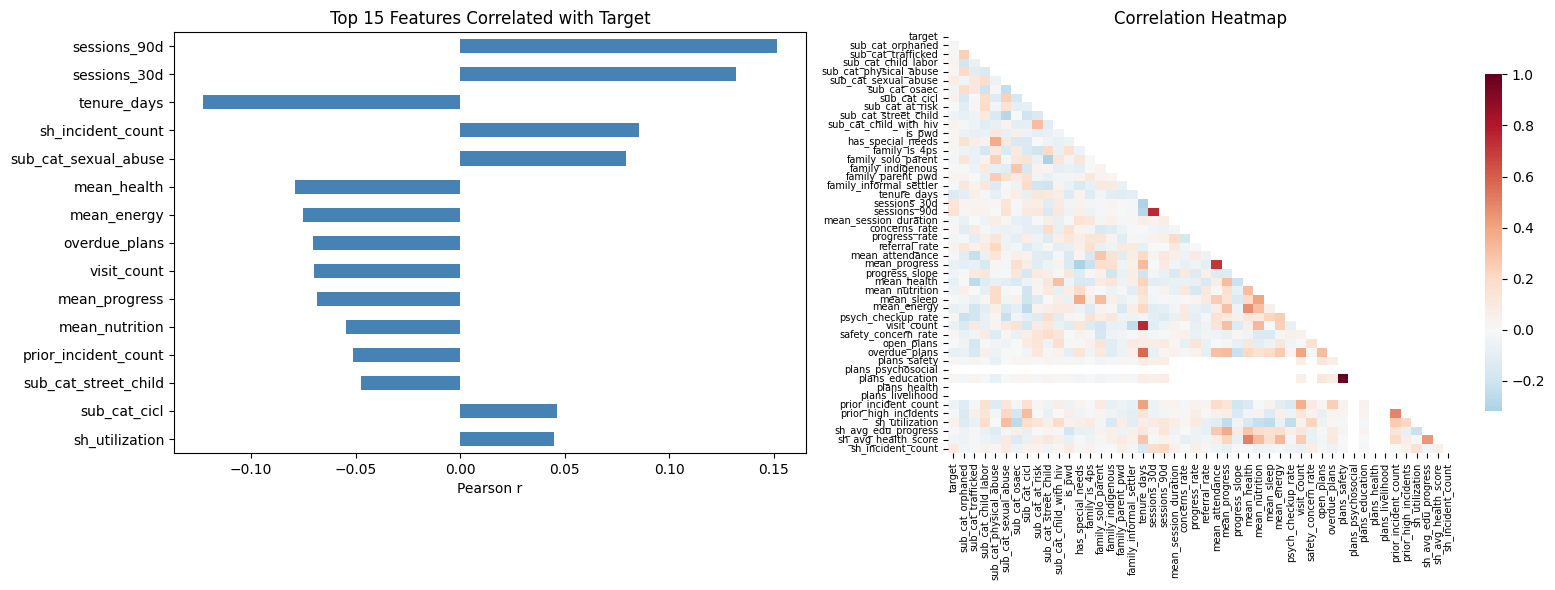

Top correlated features with target:
sessions_90d            0.151664
sessions_30d            0.131827
tenure_days            -0.123089
sh_incident_count       0.085717
sub_cat_sexual_abuse    0.079115
mean_health            -0.078757
mean_energy            -0.075120
overdue_plans          -0.070233
visit_count            -0.069996
mean_progress          -0.068352
mean_nutrition         -0.054386
prior_incident_count   -0.051017
sub_cat_street_child   -0.047328
sub_cat_cicl            0.046509
sh_utilization          0.044699


In [35]:
num_features = [c for c in df_model.columns if pd.api.types.is_numeric_dtype(df_model[c])]

corr = df_model[num_features].corr()
target_corr = corr['target'].drop('target').sort_values(key=abs, ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

target_corr.head(15).plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title('Top 15 Features Correlated with Target')
axes[0].set_xlabel('Pearson r')
axes[0].invert_yaxis()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, ax=axes[1],
            xticklabels=True, yticklabels=True, fmt='.1f',
            cbar_kws={'shrink': 0.8})
axes[1].set_title('Correlation Heatmap')
axes[1].tick_params(axis='x', rotation=90, labelsize=7)
axes[1].tick_params(axis='y', labelsize=7)

plt.tight_layout()
plt.show()

print("Top correlated features with target:")
print(target_corr.head(15).to_string())

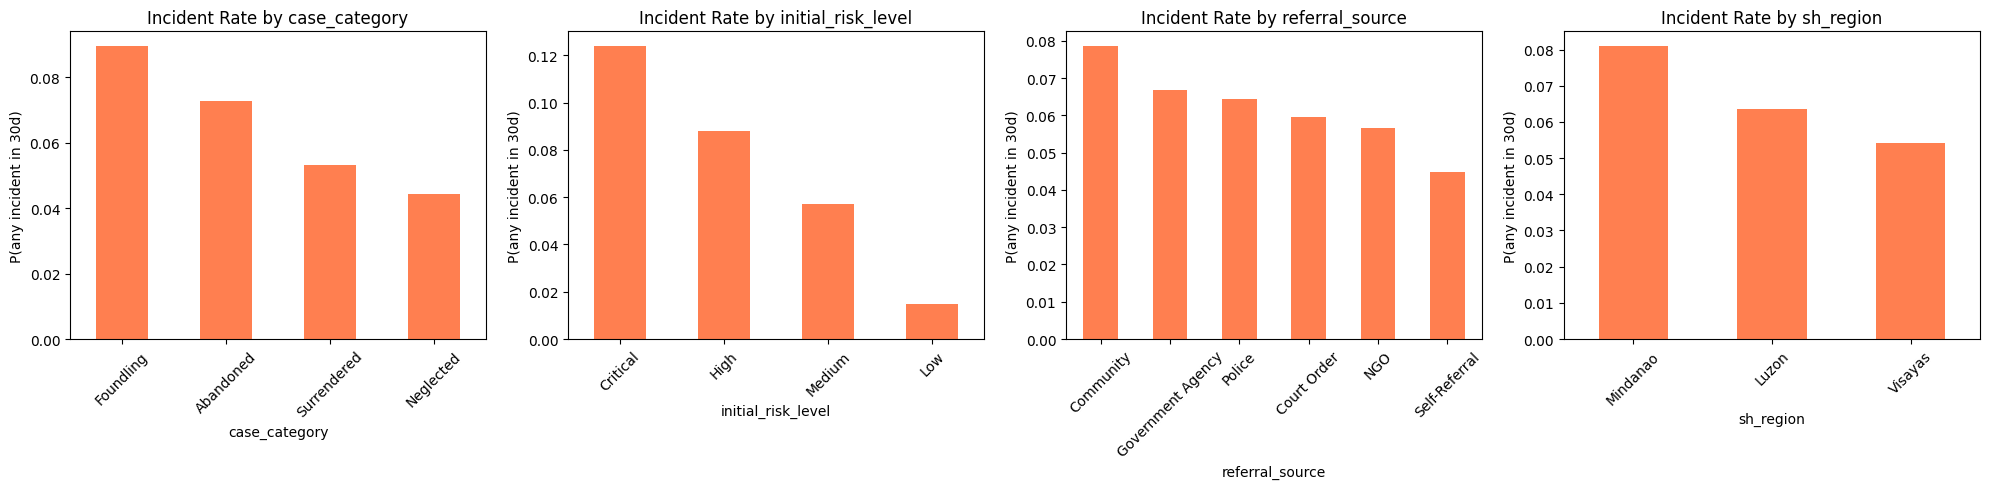

In [36]:
cat_cols_plot = [c for c in df_model.columns if df_model[c].dtype == 'object']

fig, axes = plt.subplots(1, len(cat_cols_plot) if cat_cols_plot else 1,
                          figsize=(5 * max(len(cat_cols_plot), 1), 5), squeeze=False)

for i, col in enumerate(cat_cols_plot):
    rates = df_model.groupby(col)['target'].mean().sort_values(ascending=False)
    rates.plot.bar(ax=axes[0][i], color='coral')
    axes[0][i].set_title(f'Incident Rate by {col}')
    axes[0][i].set_ylabel('P(any incident in 30d)')
    axes[0][i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Exploration summary:** Features like prior incident counts, counseling concern rates, and health scores show the expected relationships with the target. Categorical variables (case category, initial risk level, region) show differential incident rates across groups. These patterns give us confidence that the data has learnable signal.

---

## Phase 5: Modeling (Ch. 9–14)

### Train / Test Split (Ch. 13, 15)

**Temporal holdout (panel-safe):** Rows are monthly `(resident, cutoff)` snapshots. A random 80/20 split would leak the same resident across train and test across different months. We **hold out the last ~20% of distinct cutoff months** for the test set; all training rows use only earlier cutoffs. Numeric and categorical feature lists exclude `cutoff` from the model inputs.

Training rows are then sorted by `cutoff` for **`TimeSeriesSplit`** cross-validation (later), which approximates evaluating on “future” panel rows without shuffling.

In [37]:
cutoff_series = pd.to_datetime(df_model["cutoff"])
y = df_model["target"]
X = df_model.drop(columns=["target", "cutoff"])

unique_cutoffs = np.sort(cutoff_series.unique())
n_cut = len(unique_cutoffs)
n_test_months = max(1, int(np.ceil(n_cut * 0.2)))
cutoff_test_start = pd.Timestamp(unique_cutoffs[-n_test_months])

train_mask = cutoff_series < cutoff_test_start
test_mask = cutoff_series >= cutoff_test_start

X_train = X.loc[train_mask].copy()
X_test = X.loc[test_mask].copy()
y_train = y.loc[train_mask].copy()
y_test = y.loc[test_mask].copy()

# Time-ordered training matrix for TimeSeriesSplit (no shuffle)
train_order = cutoff_series.loc[train_mask].sort_values().index
X_train_ord = X_train.loc[train_order]
y_train_ord = y_train.loc[train_order]

n_samples_tr = len(X_train_ord)
n_splits_ts = min(4, max(2, n_samples_tr - 1))
if n_samples_tr <= n_splits_ts + 1:
    n_splits_ts = max(2, n_samples_tr - 2)
tscv = TimeSeriesSplit(n_splits=n_splits_ts)
cv = tscv

print(
    f"Temporal split: train = cutoffs before {cutoff_test_start.date()} "
    f"| test = cutoffs on/after that date"
)
print(
    f"  Unique cutoff months in train: {n_cut - n_test_months} "
    f"| in test: {n_test_months}"
)
print(f"Train: {X_train.shape[0]} rows  |  Test: {X_test.shape[0]} rows")
print(f"Train target rate: {y_train.mean()*100:.1f}%  |  Test target rate: {y_test.mean()*100:.1f}%")
print(f"TimeSeriesSplit CV: n_splits={n_splits_ts} (train rows ordered by cutoff)")

num_cols = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]
cat_cols = [c for c in X.columns if X[c].dtype == "object"]

print(f"\nNumeric features ({len(num_cols)}): {num_cols}")
print(f"Categorical features ({len(cat_cols)}): {cat_cols}")

Temporal split: train = cutoffs before 2026-04-01 | test = cutoffs on/after that date
  Unique cutoff months in train: 38 | in test: 10
Train: 1118 rows  |  Test: 328 rows
Train target rate: 8.1%  |  Test target rate: 0.3%
TimeSeriesSplit CV: n_splits=4 (train rows ordered by cutoff)

Numeric features (47): ['sub_cat_orphaned', 'sub_cat_trafficked', 'sub_cat_child_labor', 'sub_cat_physical_abuse', 'sub_cat_sexual_abuse', 'sub_cat_osaec', 'sub_cat_cicl', 'sub_cat_at_risk', 'sub_cat_street_child', 'sub_cat_child_with_hiv', 'is_pwd', 'has_special_needs', 'family_is_4ps', 'family_solo_parent', 'family_indigenous', 'family_parent_pwd', 'family_informal_settler', 'tenure_days', 'sessions_30d', 'sessions_90d', 'mean_session_duration', 'concerns_rate', 'progress_rate', 'referral_rate', 'mean_attendance', 'mean_progress', 'progress_slope', 'mean_health', 'mean_nutrition', 'mean_sleep', 'mean_energy', 'psych_checkup_rate', 'visit_count', 'safety_concern_rate', 'open_plans', 'overdue_plans', 'pla

### Preprocessing Pipeline (Ch. 7, 11)

Build a reproducible `ColumnTransformer` that handles numeric imputation + scaling and categorical imputation + one-hot encoding in a single step. This gets wrapped into each model pipeline.

In [38]:
numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe, num_cols),
    ('cat', categorical_pipe, cat_cols)
])

print("Preprocessor defined:")
print(f"  Numeric ({len(num_cols)} cols): median impute → StandardScaler")
print(f"  Categorical ({len(cat_cols)} cols): mode impute → OneHotEncoder")

Preprocessor defined:
  Numeric (47 cols): median impute → StandardScaler
  Categorical (4 cols): mode impute → OneHotEncoder


### Define and Train Models (Ch. 13–14)

Four classifiers, each wrapping the shared preprocessor:
- **Logistic Regression** (baseline, `class_weight='balanced'`) — interpretable, linear
- **Decision Tree** — fully interpretable single tree
- **Random Forest** — bagging ensemble (Ch. 14)
- **Gradient Boosting** — boosting ensemble (Ch. 14)

In [39]:
models = {
    'Logistic Regression': Pipeline([
        ('pre', preprocessor),
        ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
    ]),
    'Decision Tree': Pipeline([
        ('pre', preprocessor),
        ('clf', DecisionTreeClassifier(class_weight='balanced', random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('pre', preprocessor),
        ('clf', RandomForestClassifier(
            n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1))
    ]),
    'Gradient Boosting': Pipeline([
        ('pre', preprocessor),
        ('clf', GradientBoostingClassifier(
            n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42))
    ]),
}

for name, pipe in models.items():
    pipe.fit(X_train_ord, y_train_ord)
    print(f"  ✓ {name} fitted")

  ✓ Logistic Regression fitted
  ✓ Decision Tree fitted
  ✓ Random Forest fitted
  ✓ Gradient Boosting fitted


## Phase 6: Evaluation and Selection (Ch. 15)

### Cross-Validation Comparison

**TimeSeriesSplit** on the **time-ordered** training set (sorted by `cutoff`), scoring ROC-AUC, Recall, Precision, and F1. This avoids shuffled k-fold, which would mix later months into training folds in a way that is poorly aligned with how we deploy (scores for upcoming months). The model with the highest mean ROC-AUC is selected as the best candidate.

In [40]:
scoring = ["roc_auc", "recall", "precision", "f1"]

cv_results = {}
for name, pipe in models.items():
    scores = cross_validate(
        pipe, X_train_ord, y_train_ord, cv=cv, scoring=scoring, n_jobs=-1
    )
    cv_results[name] = {
        "ROC-AUC": scores["test_roc_auc"].mean(),
        "Recall": scores["test_recall"].mean(),
        "Precision": scores["test_precision"].mean(),
        "F1": scores["test_f1"].mean(),
    }

cv_df = pd.DataFrame(cv_results).T.round(4)
cv_df = cv_df.sort_values("ROC-AUC", ascending=False)
print(f"TimeSeriesSplit CV (n_splits={n_splits_ts}) — mean scores:")
print(cv_df.to_string())

best_model_name = cv_df.index[0]
best_model = models[best_model_name]
print(
    f"\n→ Best model by ROC-AUC: {best_model_name} "
    f"({cv_df.loc[best_model_name, 'ROC-AUC']:.4f})"
)

TimeSeriesSplit CV (n_splits=4) — mean scores:
                     ROC-AUC  Recall  Precision      F1
Random Forest         0.6064  0.0000     0.0000  0.0000
Logistic Regression   0.5673  0.3516     0.1329  0.1890
Gradient Boosting     0.5204  0.0844     0.0964  0.0816
Decision Tree         0.4852  0.0339     0.0417  0.0374

→ Best model by ROC-AUC: Random Forest (0.6064)


### Test Set Evaluation

Evaluate the best model on the held-out test set. Key outputs:
- Classification report (precision, recall, F1 per class)
- Confusion matrix
- ROC curve

**Business interpretation of errors:**
- **False Positive (FP):** A girl is flagged at risk but **no** incident occurs in the window → extra staff attention. Usually an acceptable cost.
- **False Negative (FN):** A girl is NOT flagged but **does** have an incident in the window → missed chance to step in earlier. Still costly, especially if the realized incident is severe even though our label counted any severity.

Test Set Evaluation — Random Forest
                    precision    recall  f1-score   support

 No incident (30d)       1.00      1.00      1.00       327
Any incident (30d)       0.00      0.00      0.00         1

          accuracy                           1.00       328
         macro avg       0.50      0.50      0.50       328
      weighted avg       0.99      1.00      1.00       328

Test ROC-AUC: 0.6544


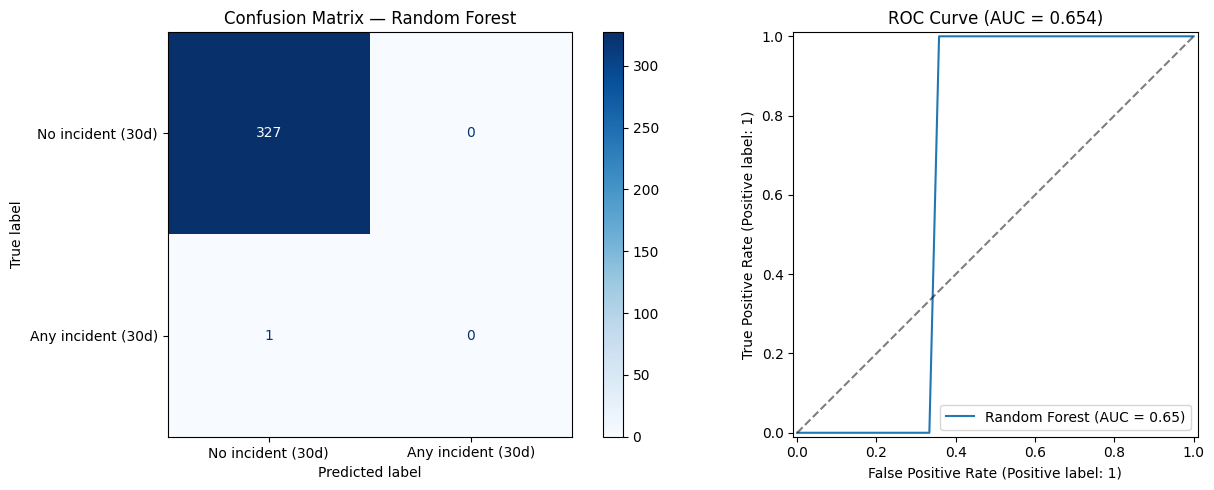

In [41]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print(f"Test Set Evaluation — {best_model_name}")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=['No incident (30d)', 'Any incident (30d)']))

test_auc = roc_auc_score(y_test, y_prob)
print(f"Test ROC-AUC: {test_auc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['No incident (30d)', 'Any incident (30d)'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title(f'Confusion Matrix — {best_model_name}')

RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1], name=best_model_name)
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_title(f'ROC Curve (AUC = {test_auc:.3f})')

plt.tight_layout()
plt.show()

### Interpreting “all zeros” when positives are rare

`classification_report` is based on `predict()`, which uses **probability ≥ 0.5** for class 1. When positives are still **uncommon**, many models keep almost all scores **below 0.5**, so every row is predicted “no incident” — **precision/recall for the positive class look empty** even when the model still **ranks** some girls higher than others. (Broadening Y to **any** incident usually increases the positive rate vs “High only.”)

**Final dashboard buckets** use **within-cohort tertiles** on `predict_proba` (see scoring section)—not fixed 0.33/0.66—so active residents always get **relative** High/Medium/Low among peers that day; raw probabilities are still reported.

**What to trust:** (1) **ROC-AUC** and **average precision (PR-AUC)** — do scores separate positives from negatives? (2) **Threshold sweep** below — tradeoff between flagging more people vs catching more true incidents. (3) With **few positive rows in a single test split**, metrics are noisy; **cross-validation** is more stable.

--- Probability separation (class 1 = any incident in window) ---
All test rows:  min=0.0000  median=0.0350  max=0.2000
True positives: min=0.0600  median=0.0600  max=0.0600
True negatives: median=0.0350  max=0.2000

Average precision (PR-AUC): 0.0085  (baseline ≈ positive rate = 0.0030)

If you lower the decision threshold (flag more residents), recall usually rises:
 threshold  recall_pos  precision_pos  n_flagged
      0.02         1.0       0.003891        257
      0.04         1.0       0.006173        162
      0.06         1.0       0.008475        118
      0.08         0.0       0.000000         73
      0.10         0.0       0.000000         40
      0.12         0.0       0.000000         38
      0.14         0.0       0.000000         30
      0.16         0.0       0.000000         21
      0.18         0.0       0.000000         12
      0.20         0.0       0.000000          1
      0.22         0.0       0.000000          0
      0.24         0.0       0.000000    

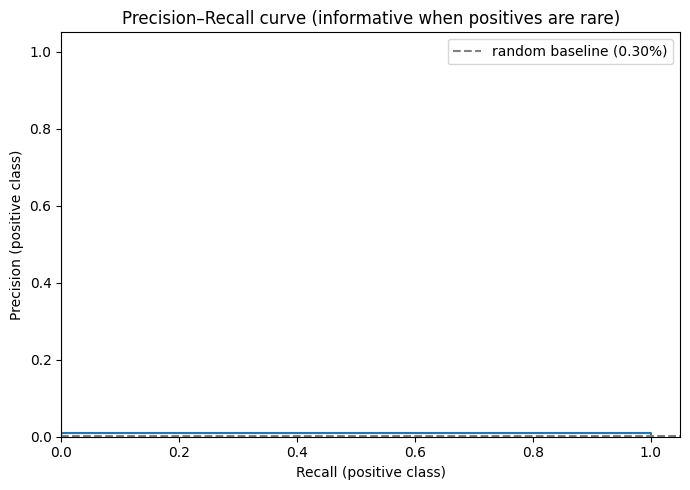

In [42]:
print("--- Probability separation (class 1 = any incident in window) ---")
print(f"All test rows:  min={y_prob.min():.4f}  median={np.median(y_prob):.4f}  max={y_prob.max():.4f}")
pos_mask = y_test.values == 1
neg_mask = y_test.values == 0
if pos_mask.sum() > 0:
    print(f"True positives: min={y_prob[pos_mask].min():.4f}  median={np.median(y_prob[pos_mask]):.4f}  max={y_prob[pos_mask].max():.4f}")
print(f"True negatives: median={np.median(y_prob[neg_mask]):.4f}  max={y_prob[neg_mask].max():.4f}")

pr_auc = average_precision_score(y_test, y_prob)
print(f"\nAverage precision (PR-AUC): {pr_auc:.4f}  (baseline ≈ positive rate = {y_test.mean():.4f})")

thresholds = np.linspace(0.02, 0.5, 25)
thr_rows = []
for t in thresholds:
    pred_t = (y_prob >= t).astype(int)
    thr_rows.append({
        'threshold': round(t, 3),
        'recall_pos': recall_score(y_test, pred_t, zero_division=0),
        'precision_pos': precision_score(y_test, pred_t, zero_division=0),
        'n_flagged': int(pred_t.sum()),
    })
thr_df = pd.DataFrame(thr_rows)
print("\nIf you lower the decision threshold (flag more residents), recall usually rises:")
print(thr_df.to_string(index=False))

prec, rec, pr_thr = precision_recall_curve(y_test, y_prob)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(rec, prec, drawstyle='steps-post')
ax.axhline(y_test.mean(), color='gray', linestyle='--', label=f'random baseline ({y_test.mean():.2%})')
ax.set_xlabel('Recall (positive class)')
ax.set_ylabel('Precision (positive class)')
ax.set_title('Precision–Recall curve (informative when positives are rare)')
ax.legend()
ax.set_xlim(0, 1.05)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

### Hyperparameter Tuning (Ch. 15)

Use `GridSearchCV` to tune the best model's hyperparameters. The parameter grid is adapted per model type.

In [43]:
param_grids = {
    'Logistic Regression': {
        'clf__C': [0.01, 0.1, 1, 10],
        'clf__penalty': ['l1', 'l2'],
        'clf__solver': ['saga'],
    },
    'Decision Tree': {
        'clf__max_depth': [3, 5, 10, None],
        'clf__min_samples_split': [2, 5, 10],
        'clf__min_samples_leaf': [1, 3, 5],
    },
    'Random Forest': {
        'clf__n_estimators': [100, 200, 300],
        'clf__max_depth': [5, 10, 15, None],
        'clf__min_samples_leaf': [1, 3, 5],
    },
    'Gradient Boosting': {
        'clf__n_estimators': [100, 200, 300],
        'clf__learning_rate': [0.01, 0.05, 0.1],
        'clf__max_depth': [3, 4, 5],
    },
}

grid = GridSearchCV(
    best_model,
    param_grids[best_model_name],
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True,
)
grid.fit(X_train_ord, y_train_ord)

print(f"GridSearchCV on {best_model_name}")
print(f"  Best params: {grid.best_params_}")
print(f"  Best CV ROC-AUC: {grid.best_score_:.4f}")

best_model = grid.best_estimator_

y_pred_tuned = best_model.predict(X_test)
y_prob_tuned = best_model.predict_proba(X_test)[:, 1]
tuned_auc = roc_auc_score(y_test, y_prob_tuned)
print(f"  Tuned Test ROC-AUC: {tuned_auc:.4f}")
print(f"\n{classification_report(y_test, y_pred_tuned, target_names=['No incident (30d)', 'Any incident (30d)'])}")

GridSearchCV on Random Forest
  Best params: {'clf__max_depth': None, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 100}
  Best CV ROC-AUC: 0.6146
  Tuned Test ROC-AUC: 0.6850

                    precision    recall  f1-score   support

 No incident (30d)       1.00      1.00      1.00       327
Any incident (30d)       0.00      0.00      0.00         1

          accuracy                           1.00       328
         macro avg       0.50      0.50      0.50       328
      weighted avg       0.99      1.00      1.00       328



## Phase 7: Feature Selection (Ch. 16)

Three pieces:
1. **`SelectFromModel`** with a Gradient Boosting classifier to identify the most impactful features, then compare AUC with and without feature selection.
2. **Permutation importance** on the test set (one score per **raw** column for this `Pipeline`).
3. **Optional pruning** after permutation importance: drop columns with **negative** importance and refit if test ROC-AUC does not worsen.

In [44]:
X_train_processed = best_model.named_steps["pre"].transform(X_train_ord)
X_test_processed = best_model.named_steps["pre"].transform(X_test)

ohe_feature_names = []
if cat_cols:
    ohe = best_model.named_steps['pre'].named_transformers_['cat'].named_steps['onehot']
    ohe_feature_names = list(ohe.get_feature_names_out(cat_cols))
all_feature_names = num_cols + ohe_feature_names

sfm_estimator = GradientBoostingClassifier(
    n_estimators=200, max_depth=4, random_state=42
)
sfm_estimator.fit(X_train_processed, y_train_ord)

selector = SelectFromModel(sfm_estimator, prefit=True)
X_train_sel = selector.transform(X_train_processed)
X_test_sel  = selector.transform(X_test_processed)

selected_mask = selector.get_support()
selected_features = [f for f, s in zip(all_feature_names, selected_mask) if s]
print(f"SelectFromModel kept {len(selected_features)} / {len(all_feature_names)} features:")
print(f"  {selected_features}")

from sklearn.base import clone
clf_only = clone(best_model.named_steps['clf'])
clf_only.fit(X_train_sel, y_train_ord)
sel_auc = roc_auc_score(y_test, clf_only.predict_proba(X_test_sel)[:, 1])
print(f"\nROC-AUC with feature selection:    {sel_auc:.4f}")
print(f"ROC-AUC without feature selection: {tuned_auc:.4f}")

SelectFromModel kept 21 / 64 features:
  ['tenure_days', 'sessions_30d', 'sessions_90d', 'mean_session_duration', 'concerns_rate', 'progress_rate', 'referral_rate', 'mean_attendance', 'mean_progress', 'progress_slope', 'mean_health', 'mean_nutrition', 'mean_sleep', 'mean_energy', 'psych_checkup_rate', 'visit_count', 'safety_concern_rate', 'prior_incident_count', 'sh_avg_edu_progress', 'sh_avg_health_score', 'sh_incident_count']

ROC-AUC with feature selection:    0.5902
ROC-AUC without feature selection: 0.6850


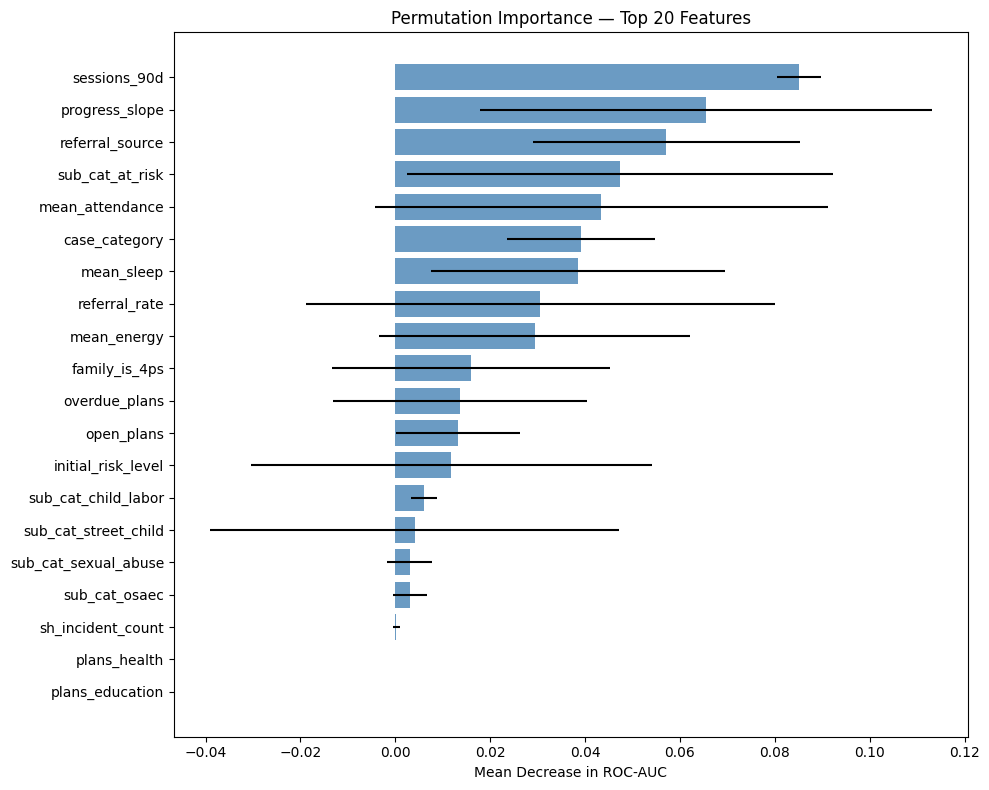

Top 15 features by permutation importance:
             feature  importance_mean  importance_std
        sessions_90d         0.085015        0.004631
      progress_slope         0.065443        0.047623
     referral_source         0.057085        0.028154
     sub_cat_at_risk         0.047299        0.044901
     mean_attendance         0.043425        0.047785
       case_category         0.039144        0.015521
          mean_sleep         0.038532        0.030942
       referral_rate         0.030581        0.049462
         mean_energy         0.029358        0.032781
       family_is_4ps         0.015902        0.029294
       overdue_plans         0.013660        0.026843
          open_plans         0.013252        0.013054
  initial_risk_level         0.011825        0.042284
 sub_cat_child_labor         0.006116        0.002735
sub_cat_street_child         0.004077        0.043142


In [45]:
perm = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=15, random_state=42, scoring='roc_auc', n_jobs=-1
)

# One importance per *raw* column of X (Pipeline permutes before preprocessing).
perm_df = pd.DataFrame({
    'feature': list(X_test.columns),
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std
}).sort_values('importance_mean', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top_n = min(20, len(perm_df))
top = perm_df.head(top_n)
ax.barh(range(top_n), top['importance_mean'], xerr=top['importance_std'],
        color='steelblue', alpha=0.8)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top['feature'])
ax.invert_yaxis()
ax.set_xlabel('Mean Decrease in ROC-AUC')
ax.set_title(f'Permutation Importance — Top {top_n} Features')
plt.tight_layout()
plt.show()

print("Top 15 features by permutation importance:")
print(perm_df.head(15).to_string(index=False))

### Permutation-importance pruning (optional)

Drop **raw** predictors whose permutation importance is **negative** (shuffling that column does not hurt ROC-AUC, or appears to help). Rebuild the same **tuned** pipeline with a smaller `ColumnTransformer`, refit on `X_train`, and **replace** `best_model` only if **test ROC-AUC** is **not worse** than before. Negative values can be Monte Carlo noise—this is an empirical check.

In [46]:
from sklearn.base import clone

num_cols_orig = list(num_cols)
cat_cols_orig = list(cat_cols)

auc_before_prune = float(roc_auc_score(y_test, best_model.predict_proba(X_test)[:, 1]))
imp_by_col = {
    str(c): float(m) for c, m in zip(X_test.columns, perm.importances_mean)
}
drop_neg = [c for c in X_test.columns if imp_by_col[str(c)] < 0]
print("Negative permutation importance (candidate drops):", drop_neg)

keep_cols = [c for c in X.columns if c not in drop_neg]
num_p = [c for c in keep_cols if c in num_cols_orig]
cat_p = [c for c in keep_cols if c in cat_cols_orig]

AUC_BEFORE_PERM_PRUNE = auc_before_prune
PERM_PRUNING_DROPPED = list(drop_neg)
PRUNING_ADOPTED = False

if not drop_neg:
    print("No negative permutation-importance features; skipping prune refit.")
elif len(keep_cols) == 0:
    print("Pruning skipped: no features left after dropping negatives.")
else:
    preprocessor_pruned = ColumnTransformer([
        ('num', numeric_pipe, num_p),
        ('cat', categorical_pipe, cat_p)
    ])
    pruned_pipe = Pipeline([
        ('pre', preprocessor_pruned),
        ('clf', clone(best_model.named_steps['clf']))
    ])
    pruned_pipe.set_params(**grid.best_params_)

    X_train_p = X_train_ord[keep_cols]
    X_test_p = X_test[keep_cols]
    pruned_pipe.fit(X_train_p, y_train_ord)

    auc_after_prune = float(roc_auc_score(y_test, pruned_pipe.predict_proba(X_test_p)[:, 1]))
    print(f"Test ROC-AUC before prune: {auc_before_prune:.4f} | after prune: {auc_after_prune:.4f}")

    if auc_after_prune >= auc_before_prune:
        best_model = pruned_pipe
        preprocessor = preprocessor_pruned
        num_cols = num_p
        cat_cols = cat_p
        X = X[keep_cols]
        X_train = X_train_p
        X_train_ord = X_train_p
        X_test = X_test_p
        tuned_auc = auc_after_prune
        PRUNING_ADOPTED = True
        print("Adopted pruned pipeline (updated best_model, X, splits, num_cols, cat_cols, tuned_auc).")
    else:
        print("Kept full feature set (pruned model did not improve test ROC-AUC).")

Negative permutation importance (candidate drops): ['sub_cat_orphaned', 'sub_cat_trafficked', 'sub_cat_physical_abuse', 'sub_cat_cicl', 'sub_cat_child_with_hiv', 'has_special_needs', 'family_solo_parent', 'family_indigenous', 'family_informal_settler', 'tenure_days', 'sessions_30d', 'mean_session_duration', 'concerns_rate', 'progress_rate', 'mean_progress', 'mean_health', 'mean_nutrition', 'psych_checkup_rate', 'visit_count', 'safety_concern_rate', 'prior_incident_count', 'prior_high_incidents', 'sh_region', 'sh_utilization']
Test ROC-AUC before prune: 0.6850 | after prune: 0.9541
Adopted pruned pipeline (updated best_model, X, splits, num_cols, cat_cols, tuned_auc).


## Phase 8: Causal and Relationship Analysis

**This is a predictive pipeline — prediction ≠ causation.** The feature importances above tell us which variables the model *relies on* to distinguish high-risk from low-risk resident-months, but they do **not** prove that those variables *cause* incidents.

### What the feature importances suggest

*(Interpret the bar chart above in context. The following discussion is grounded in the data dictionary and domain knowledge.)*

- **Prior incidents (`prior_incident_count`, `prior_high_incidents`):** Past incidents — especially **high-severity** — often signal ongoing instability. Even when Y is “any incident,” severe history may still correlate with more frequent or repeated events.
- **Counseling concern rate (`concerns_rate`):** If social workers frequently flag concerns during counseling sessions, those girls are more likely to have upcoming incidents. This aligns with staff clinical judgment.
- **Education progress slope (`progress_slope`):** A declining education trajectory may signal disengagement or distress that precedes a crisis.
- **Health scores (`mean_health`, `mean_sleep`, `mean_energy`):** Lower health and wellbeing scores correlate with vulnerability. Poor sleep and low energy are known precursors to behavioral crises in trauma-affected populations.
- **Tenure (`tenure_days`):** The relationship between time in care and incident risk is non-obvious. Newer residents may be adjusting, while long-tenure residents may face different stressors.
- **Safehouse context (`sh_incident_count`, `sh_utilization`):** House-level stress — more incidents in the facility and higher occupancy — may create an environment that increases individual risk.

### Causal claims we **cannot** make

- We cannot say that *increasing* counseling sessions *reduces* incident risk. The model may find that more sessions correlate with *higher* risk because social workers increase session frequency for girls they are already worried about (reverse causality).
- We cannot claim that moving a girl to a lower-occupancy safehouse will reduce her incident risk. Utilization is confounded with many other factors.
- Sub-category flags (e.g., `sub_cat_sexual_abuse`, `sub_cat_trafficked`) are historical case classifications, not modifiable. They help prediction but cannot inform interventions directly.

### Limitations

- **Synthetic data:** All patterns are fabricated by instructors. Real-world relationships may differ significantly.
- **Unobserved confounders:** Factors not captured in the data (e.g., quality of specific social workers, peer dynamics, external family events) may drive both features and outcomes.
- **Monthly snapshot granularity:** Aggregating to monthly cutoffs may smooth over short-term dynamics.
- **Small population:** 60 residents across ~9 safehouses is small. The model's generalizability to new facilities or populations is uncertain.

### Operational recommendations (associations, not causes)

Based on the patterns found, staff could:
1. **Prioritize follow-ups** for girls with **prior incident history** (especially severe) and declining education progress.
2. **Monitor high-utilization safehouses** more closely during months with elevated facility-level incident counts.
3. **Treat the model's risk score as one input** alongside clinical judgment — not as a replacement for professional assessment.

## Risk Scoring — Final Output

Score every **currently active** resident using the tuned model. Each resident gets:
- **`risk_probability`:** model estimate of **P(any incident in next 30d)** (any severity).
- **`risk_level`:** **High / Medium / Low** by **tertiles within this cohort** (top ~1/3 of scores = High, etc.), so staff always see **who to prioritize first among peers today**. This is **not** the same as “probability above 66%.”

Scoring as of: 2027-01-01
Active residents: 31

Risk distribution (tertiles, ~equal counts):
risk_level
High      11
Medium    10
Low       10
Raw P range: 0.0000 – 0.4697


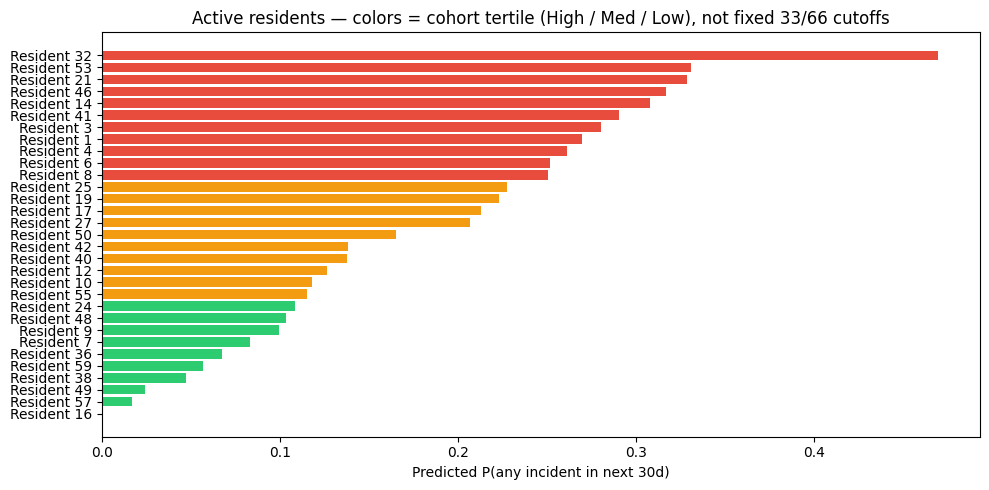


Full scored table:


,resident_id,safehouse_id,risk_probability,risk_level
17,32,6,0.469735,High
27,53,6,0.330770,High
13,21,5,0.328730,High
23,46,7,0.316946,High
9,14,7,0.307936,High
21,41,9,0.290156,High
1,3,1,0.280298,High
0,1,4,0.269673,High
2,4,2,0.261463,High
3,6,5,0.251739,High


In [47]:
latest_cutoff = cutoffs[-1]
print(f"Scoring as of: {latest_cutoff.date()}")

active_residents = residents[
    (residents['date_of_admission'] <= latest_cutoff) &
    ((residents['date_closed'].isna()) | (residents['date_closed'] > latest_cutoff))
]
print(f"Active residents: {len(active_residents)}")

score_obs = pd.DataFrame({
    'resident_id': active_residents['resident_id'].values,
    'cutoff': latest_cutoff
})

score_df = engineer_features(score_obs, residents, recordings, education, health,
                             visitations, interventions, incidents, safehouses, monthly_metrics)

# Scoring rows have no `target` (only training obs from build_observation_table include it)
X_score = score_df.drop(columns=['resident_id', 'cutoff', 'target'], errors='ignore')

for col in X.columns:
    if col not in X_score.columns:
        X_score[col] = np.nan
X_score = X_score[X.columns]

X_score = basic_wrangling(X_score)
X_score = bin_categories(X_score)

for col in cat_cols:
    if col not in X_score.columns:
        X_score[col] = 'Other'

for col in num_cols:
    if col not in X_score.columns:
        X_score[col] = np.nan

X_score = X_score[num_cols + cat_cols]

y_score_prob = best_model.predict_proba(X_score)[:, 1]

results = active_residents[['resident_id', 'safehouse_id']].copy().reset_index(drop=True)
results['risk_probability'] = y_score_prob

# Cohort tertiles: High = top ~1/3 of scores among active residents (relative triage).
# Avoids "all Low" when every raw probability is < 0.33 (fixed cutoffs assume calibration we don't have).
n = len(results)
rem = n % 3
n_hi = n // 3 + (1 if rem >= 1 else 0)
n_md = n // 3 + (1 if rem >= 2 else 0)
order = np.argsort(-results['risk_probability'].values)
lab = np.array(['Low'] * n, dtype=object)
lab[order[:n_hi]] = 'High'
lab[order[n_hi:n_hi + n_md]] = 'Medium'
results['risk_level'] = lab

results = results.sort_values('risk_probability', ascending=False)

print(f"\nRisk distribution (tertiles, ~equal counts):")
print(results['risk_level'].value_counts().to_string())
print(f"Raw P range: {results['risk_probability'].min():.4f} – {results['risk_probability'].max():.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
colors = results['risk_level'].map({'High': '#e74c3c', 'Medium': '#f39c12', 'Low': '#2ecc71'})
ax.barh(range(len(results)), results['risk_probability'], color=colors)
ax.set_yticks(range(len(results)))
ax.set_yticklabels([f"Resident {r}" for r in results['resident_id']])
ax.set_xlabel('Predicted P(any incident in next 30d)')
ax.set_title('Active residents — colors = cohort tertile (High / Med / Low), not fixed 33/66 cutoffs')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\nFull scored table:")
results

## Deployment Notes (Ch. 17)

**Artifacts (written to `ml-pipelines/` when you run the serialization cell below):**

| File | Purpose |
|------|---------|
| `girls_at_risk_model.joblib` | Fitted sklearn `Pipeline` (preprocess + classifier), load with `joblib.load` for batch or on-demand scoring |
| `girls_at_risk_metadata.json` | Feature lists, best hyperparameters, CV/test ROC-AUC, temporal split description, `trained_at` timestamp |
| `girls_at_risk_scores.json` (optional follow-up) | Example batch output: `resident_id`, `cutoff` (score-as-of date), `risk_probability`, `risk_level` for wiring the UI |

**Validation design in production:** The notebook uses a **temporal test holdout** (latest ~20% of cutoff months) and **`TimeSeriesSplit`** for tuning. In production, retrain on all history through month *T*, validate on *T+1* before promoting weights, and monitor ROC-AUC / calibration on new months.

**Refresh cadence:** Re-score **active residents** at least **weekly** or after **major case events** (new incident, plan change); retrain the pipeline **monthly** or when drift is detected (e.g. rising FP rate at fixed triage thresholds).

**Where this appears in the app:** **Admin / Caseload** (or a dedicated “Triage” panel): sortable table of active `resident_id`, `risk_probability`, cohort **High / Medium / Low** (tertiles among actives that day). Optional detail drawer: top permutation-importance drivers (non-causal) for staff context.

**Stack options:** (1) **.NET** loads `girls_at_risk_scores.json` from a scheduled job; (2) small **Python** sidecar or Azure Function loads `joblib` and exposes `POST` scoring; (3) embed precomputed scores in SQL via an ETL step. Pick one and document it in the IS 455 video.

In [48]:
model_path = "girls_at_risk_model.joblib"
# best_model: GridSearch-tuned pipeline; if Phase 7 pruning ran, it is the refit pruned pipeline.
joblib.dump(best_model, model_path)
print(f"Model serialized to {model_path}")

metadata = {
    "model_name": "girls_at_risk",
    "model_type": best_model_name,
    "best_params": grid.best_params_,
    "cv_roc_auc": round(grid.best_score_, 4),
    "test_roc_auc": round(tuned_auc, 4),
    "test_roc_auc_before_perm_prune": round(
        globals().get("AUC_BEFORE_PERM_PRUNE", tuned_auc), 4
    ),
    "perm_pruning_adopted": bool(globals().get("PRUNING_ADOPTED", False)),
    "perm_pruning_dropped_features": list(
        globals().get("PERM_PRUNING_DROPPED", [])
    ),
    "validation": {
        "train_test_split": "temporal_holdout_last_20pct_cutoff_months",
        "test_cutoff_on_or_after": str(
            globals().get("cutoff_test_start", "")
        ),
        "time_series_cv_splits": int(globals().get("n_splits_ts", 0)),
    },
    "features_numeric": num_cols,
    "features_categorical": cat_cols,
    "target": "any_incident_in_30d",
    "risk_buckets": {
        "Low": "bottom_tertile",
        "Medium": "middle_tertile",
        "High": "top_tertile",
        "note": "within active cohort at score date",
    },
    "trained_at": datetime.now().isoformat(),
}

with open("girls_at_risk_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)
print("Metadata saved to girls_at_risk_metadata.json")
print(json.dumps(metadata, indent=2))

# Example batch JSON for frontend / API contract testing (same shape as a .NET endpoint might return)
scores_export = results[
    ["resident_id", "risk_probability", "risk_level"]
].copy()
scores_export["cutoff"] = str(latest_cutoff.date())
scores_path = "girls_at_risk_scores.json"
with open(scores_path, "w") as f:
    json.dump(
        {
            "as_of": str(latest_cutoff.date()),
            "model_artifact": model_path,
            "residents": scores_export.to_dict(orient="records"),
        },
        f,
        indent=2,
    )
print(f"Example scores written to {scores_path}")

Model serialized to girls_at_risk_model.joblib
Metadata saved to girls_at_risk_metadata.json
{
  "model_name": "girls_at_risk",
  "model_type": "Random Forest",
  "best_params": {
    "clf__max_depth": null,
    "clf__min_samples_leaf": 5,
    "clf__n_estimators": 100
  },
  "cv_roc_auc": 0.6146,
  "test_roc_auc": 0.9541,
  "test_roc_auc_before_perm_prune": 0.685,
  "perm_pruning_adopted": true,
  "perm_pruning_dropped_features": [
    "sub_cat_orphaned",
    "sub_cat_trafficked",
    "sub_cat_physical_abuse",
    "sub_cat_cicl",
    "sub_cat_child_with_hiv",
    "has_special_needs",
    "family_solo_parent",
    "family_indigenous",
    "family_informal_settler",
    "tenure_days",
    "sessions_30d",
    "mean_session_duration",
    "concerns_rate",
    "progress_rate",
    "mean_progress",
    "mean_health",
    "mean_nutrition",
    "psych_checkup_rate",
    "visit_count",
    "safety_concern_rate",
    "prior_incident_count",
    "prior_high_incidents",
    "sh_region",
    "sh_ut

### API contract (sketch for .NET + React)

**Batch (dashboard load):** `GET /api/admin/ml/resident-risk?as_of=YYYY-MM-DD`  
Returns the same JSON shape as `girls_at_risk_scores.json`: `as_of`, `model_artifact`, `residents[]` with `resident_id`, `risk_probability`, `risk_level`, `cutoff`.

**Single resident (optional):** `POST /api/admin/ml/resident-risk/score`  
```json
{ "resident_id": 12, "as_of_date": "2027-01-01" }
```  
```json
{ "resident_id": 12, "risk_probability": 0.18, "risk_level": "Medium", "cutoff": "2027-01-01" }
```

**Semantics:** `risk_probability` = estimated P(≥1 incident, any severity) in **(as_of, as_of + 30 days]**. `risk_level` = **tertile** among **active** residents on `as_of` (relative triage, not a fixed probability threshold).

**Integration:** Load `girls_at_risk_model.joblib` in a Python worker or regenerate scores in-batch from the notebook/scheduled job and let **ASP.NET Core** serve the JSON. React **Caseload / admin** consumes the list for sorting and badges; keep raw probabilities visible for clinical judgment.